<a href="https://colab.research.google.com/github/mohammedqaidamanlift-hub/-NEUROCORTEX/blob/main/NeuroCortex_SRDF_Toy_Prototype_v2.0_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 **NeuroCortex SRDF Toy Prototype v2.0**

In [ ]:
# ============================================================
# NeuroCortex SRDF Toy Prototype v2.0
# Experimental Run Infrastructure
# ============================================================
#
# Purpose:
#   Establish the permanent experimental-record infrastructure
#   used by the NeuroCortex prototype.
#
# Scientific principles:
#   - No hard-coded experimental results.
#   - Every execution receives a unique Run ID.
#   - Every Run is persisted independently.
#   - Successful and failed Runs are both retained.
#   - Failures are recorded with phase and error information.
#   - Results are produced only by actual execution.
#   - Run summaries must be computed from persisted Runs.
#
# This cell defines infrastructure only.
# It does NOT execute the NeuroCortex experiment.
# ============================================================


# ============================================================
# 0. Installation
# ============================================================

!pip -q install scikit-learn imbalanced-learn numpy pandas matplotlib seaborn


# ============================================================
# 1. Imports
# ============================================================

import json
import os
import sys
import platform
import hashlib
import uuid
import secrets
import traceback

from copy import deepcopy
from datetime import datetime, timezone


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.datasets import make_classification
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)


from imblearn.over_sampling import SMOTE


# ============================================================
# 2. Experimental Configuration
# ============================================================

# Base seed used by the current prototype.
#
# The actual seed used by each Run is stored inside that Run.
# This value is part of the experiment configuration and can
# be changed deliberately for another experimental series.
SEED = 42


# Hybrid Arbiter weights
W_ACC = 0.50
W_SAFETY = 0.30
W_EFFICIENCY = 0.20


# Arbiter acceptance threshold
THETA = 0.85


# Maximum allowed resource cost
RESOURCE_BUDGET = 3.0


# Maximum consecutive rejection count
K_MAX = 3


# Class-imbalance detection threshold
IMBALANCE_THRESHOLD = 3.0


# ============================================================
# 3. Experimental Record Storage
# ============================================================

EXPERIMENT_ROOT = "experiment_records"

RUNS_DIR = os.path.join(
    EXPERIMENT_ROOT,
    "runs",
)

SUCCESSFUL_RUNS_FILE = os.path.join(
    EXPERIMENT_ROOT,
    "successful_runs.jsonl",
)

FAILED_RUNS_FILE = os.path.join(
    EXPERIMENT_ROOT,
    "failed_runs.jsonl",
)

SUMMARY_FILE = os.path.join(
    EXPERIMENT_ROOT,
    "experiment_summary.json",
)


os.makedirs(
    RUNS_DIR,
    exist_ok=True,
)


# ============================================================
# 4. Experimental Schema
# ============================================================

RUN_SCHEMA_VERSION = "1.0.0"

PROTOTYPE_NAME = (
    "NeuroCortex SRDF Toy Prototype"
)

PROTOTYPE_VERSION = "2.0.0"


# ============================================================
# 5. Time Utilities
# ============================================================

def utc_timestamp():
    """
    Return the current UTC time in ISO-8601 format.
    """
    return datetime.now(
        timezone.utc
    ).isoformat()


# ============================================================
# 6. Run Identification
# ============================================================

def create_run_id():
    """
    Create a globally unique Run ID.

    The UUID component prevents collisions even when multiple
    Runs are created within the same second.
    """

    timestamp = datetime.now(
        timezone.utc
    ).strftime(
        "%Y%m%dT%H%M%S"
    )

    unique_part = uuid.uuid4().hex

    return (
        f"RUN-{timestamp}-"
        f"{unique_part}"
    )


def create_session_id():
    """
    Create a unique experimental session identifier.
    """

    return (
        f"SESSION-"
        f"{uuid.uuid4().hex}"
    )


SESSION_ID = create_session_id()


# ============================================================
# 7. Seed Handling
# ============================================================

def create_run_seed():
    """
    Generate a seed for a Run.

    The generated seed is persisted in the Run record, making
    that Run reproducible even though successive Runs can use
    different seeds.
    """

    return int(
        secrets.randbelow(
            2**32
        )
    )


# ============================================================
# 8. Environment Information
# ============================================================

def get_package_version(
    package_name,
):
    """
    Return the installed package version.

    Returns None if the package metadata cannot be resolved.
    """

    try:
        from importlib.metadata import version

        return version(
            package_name
        )

    except Exception:
        return None


def get_environment_record():
    """
    Capture the execution environment required for
    reproducibility and auditability.
    """

    return {
        "python_version": sys.version,
        "python_implementation":
            platform.python_implementation(),

        "platform":
            platform.platform(),

        "system":
            platform.system(),

        "release":
            platform.release(),

        "machine":
            platform.machine(),

        "processor":
            platform.processor(),

        "numpy_version":
            np.__version__,

        "pandas_version":
            pd.__version__,

        "scikit_learn_version":
            get_package_version(
                "scikit-learn"
            ),

        "imbalanced_learn_version":
            get_package_version(
                "imbalanced-learn"
            ),

        "matplotlib_version":
            get_package_version(
                "matplotlib"
            ),

        "seaborn_version":
            get_package_version(
                "seaborn"
            ),
    }


# ============================================================
# 9. Stable Hashing
# ============================================================

def stable_hash(
    value,
):
    """
    Create a deterministic SHA-256 fingerprint for a
    JSON-compatible object.
    """

    serialized = json.dumps(
        value,
        sort_keys=True,
        ensure_ascii=False,
        default=str,
    ).encode(
        "utf-8"
    )

    return hashlib.sha256(
        serialized
    ).hexdigest()


# ============================================================
# 10. Configuration Definition
# ============================================================

def get_experiment_configuration():
    """
    Return the complete configuration that controls the
    current NeuroCortex prototype.
    """

    return {
        "arbiter_weights": {
            "accuracy":
                float(W_ACC),

            "safety":
                float(W_SAFETY),

            "efficiency":
                float(W_EFFICIENCY),
        },

        "arbiter_threshold":
            float(THETA),

        "resource_budget":
            float(RESOURCE_BUDGET),

        "rejection_limit":
            int(K_MAX),

        "imbalance_threshold":
            float(
                IMBALANCE_THRESHOLD
            ),
    }


# ============================================================
# 11. Atomic JSON Persistence
# ============================================================

def atomic_json_write(
    path,
    data,
):
    """
    Write JSON atomically.

    The temporary file is written first and then replaced,
    reducing the risk of leaving a partially written Run file.
    """

    directory = os.path.dirname(
        path
    )

    if directory:
        os.makedirs(
            directory,
            exist_ok=True,
        )

    temporary_path = (
        f"{path}.tmp"
    )

    with open(
        temporary_path,
        "w",
        encoding="utf-8",
    ) as file:

        json.dump(
            data,
            file,
            indent=2,
            ensure_ascii=False,
            sort_keys=True,
        )

        file.flush()
        os.fsync(
            file.fileno()
        )

    os.replace(
        temporary_path,
        path,
    )


# ============================================================
# 12. JSONL Persistence
# ============================================================

def append_jsonl(
    path,
    record,
):
    """
    Append one finalized Run record to a JSONL ledger.
    """

    with open(
        path,
        "a",
        encoding="utf-8",
    ) as file:

        file.write(
            json.dumps(
                record,
                ensure_ascii=False,
                sort_keys=True,
                default=str,
            )
            + "\n"
        )

        file.flush()

        os.fsync(
            file.fileno()
        )


# ============================================================
# 13. Run File Path
# ============================================================

def get_run_path(
    run_id,
):
    """
    Return the persistent path of an individual Run.
    """

    return os.path.join(
        RUNS_DIR,
        f"{run_id}.json",
    )


# ============================================================
# 14. Run Record Factory
# ============================================================

def create_run_record(
    run_seed=None,
):
    """
    Create the initial record for one real experimental Run.

    No experimental results are generated here.
    """

    if run_seed is None:
        run_seed = create_run_seed()

    configuration = (
        get_experiment_configuration()
    )

    run_id = create_run_id()

    record = {

        "schema_version":
            RUN_SCHEMA_VERSION,

        "prototype":
            PROTOTYPE_NAME,

        "prototype_version":
            PROTOTYPE_VERSION,

        "run_id":
            run_id,

        "session_id":
            SESSION_ID,

        "started_at":
            utc_timestamp(),

        "finished_at":
            None,

        "status":
            "RUNNING",

        "phase":
            "INITIALIZATION",

        "seed":
            int(run_seed),

        "environment":
            get_environment_record(),

        "configuration":
            configuration,

        "configuration_fingerprint":
            stable_hash(
                configuration
            ),

        "dataset":
            {},

        "execution":
            {},

        "baseline":
            {},

        "context":
            {},

        "trawler":
            {},

        "candidates":
            [],

        "invariants":
            {},

        "arbiter":
            {},

        "decisions":
            [],

        "outcome":
            {},

        "validity":
            {
                "eligible_for_statistics":
                    False,

                "reason":
                    "Run has not completed.",
            },

        "error":
            None,
    }

    return record


# ============================================================
# 15. Run Persistence
# ============================================================

def persist_run(
    record,
):
    """
    Persist the current state of a Run.

    RUNNING records are persisted only to their individual
    Run file.

    SUCCESS and FAILURE records are additionally appended
    to their corresponding immutable JSONL ledger.
    """

    run_id = record[
        "run_id"
    ]

    run_path = get_run_path(
        run_id
    )

    atomic_json_write(
        run_path,
        record,
    )

    status = record[
        "status"
    ]

    if status == "SUCCESS":

        append_jsonl(
            SUCCESSFUL_RUNS_FILE,
            record,
        )

    elif status == "FAILURE":

        append_jsonl(
            FAILED_RUNS_FILE,
            record,
        )

    elif status in {
        "RUNNING",
        "INTERRUPTED",
    }:

        pass

    else:

        raise ValueError(
            "Unsupported Run status: "
            f"{status}"
        )


# ============================================================
# 16. Run Phase Tracking
# ============================================================

def set_run_phase(
    record,
    phase,
):
    """
    Update the current execution phase and persist the Run.
    """

    record[
        "phase"
    ] = str(
        phase
    )

    persist_run(
        record
    )


# ============================================================
# 17. Run Success Finalization
# ============================================================

def finalize_run_success(
    record,
    eligible_for_statistics=True,
):
    """
    Finalize a successfully completed Run.

    Eligibility for statistics is explicitly recorded rather
    than inferred later from the presence of a result file.
    """

    record[
        "finished_at"
    ] = utc_timestamp()

    record[
        "status"
    ] = "SUCCESS"

    record[
        "phase"
    ] = "COMPLETED"

    record[
        "validity"
    ] = {

        "eligible_for_statistics":
            bool(
                eligible_for_statistics
            ),

        "reason":
            (
                "Completed Run."
                if eligible_for_statistics
                else
                "Completed Run but excluded "
                "from final statistics."
            ),
    }

    persist_run(
        record
    )


# ============================================================
# 18. Run Failure Finalization
# ============================================================

def finalize_run_failure(
    record,
    error,
    phase=None,
):
    """
    Finalize and persist a failed Run.

    The failure itself is retained as experimental evidence.
    """

    if phase is not None:

        record[
            "phase"
        ] = str(
            phase
        )

    record[
        "finished_at"
    ] = utc_timestamp()

    record[
        "status"
    ] = "FAILURE"

    record[
        "validity"
    ] = {

        "eligible_for_statistics":
            False,

        "reason":
            "Run failed before valid completion.",
    }

    record[
        "error"
    ] = {

        "error_type":
            type(
                error
            ).__name__,

        "error_message":
            str(
                error
            ),

        "traceback":
            traceback.format_exc(),
    }

    persist_run(
        record
    )


# ============================================================
# 19. JSON-Safe Conversion
# ============================================================

def make_json_safe(
    value,
):
    """
    Convert common NumPy/Pandas objects into JSON-safe
    representations without changing experimental values.
    """

    if isinstance(
        value,
        np.generic,
    ):

        return value.item()


    if isinstance(
        value,
        np.ndarray,
    ):

        return value.tolist()


    if isinstance(
        value,
        pd.DataFrame,
    ):

        return value.to_dict(
            orient="records"
        )


    if isinstance(
        value,
        pd.Series,
    ):

        return value.tolist()


    if isinstance(
        value,
        dict,
    ):

        return {
            str(key):
                make_json_safe(
                    val
                )

            for key, val
            in value.items()
        }


    if isinstance(
        value,
        (list, tuple),
    ):

        return [
            make_json_safe(
                item
            )
            for item in value
        ]


    if isinstance(
        value,
        float,
    ):

        if np.isnan(
            value
        ):

            return None

        if np.isinf(
            value
        ):

            return (
                "Infinity"
                if value > 0
                else
                "-Infinity"
            )


    return value


# ============================================================
# 20. Current Run Initialization
# ============================================================

CURRENT_RUN = create_run_record(
    run_seed=SEED
)


# ============================================================
# 21. Persist Initial RUNNING State
# ============================================================

persist_run(
    CURRENT_RUN
)


# ============================================================
# 22. Scientific Runtime Initialization
# ============================================================

np.random.seed(
    CURRENT_RUN["seed"]
)


# ============================================================
# 23. Notebook Runtime Failure Hook
# ============================================================

def _neurocortex_post_run_cell(
    result,
):
    """
    Capture exceptions raised by later notebook cells.

    If a later cell fails, the current Run is automatically
    finalized as FAILURE and persisted.

    This does not replace explicit phase tracking. Later cells
    should still update CURRENT_RUN['phase'] before executing
    important operations.
    """

    global CURRENT_RUN

    if CURRENT_RUN is None:
        return

    if CURRENT_RUN.get(
        "status"
    ) != "RUNNING":

        return

    error = getattr(
        result,
        "error_in_exec",
        None,
    )

    if error is None:
        return

    phase = CURRENT_RUN.get(
        "phase",
        "UNKNOWN",
    )

    try:

        finalize_run_failure(
            CURRENT_RUN,
            error=error,
            phase=phase,
        )

    except Exception as persistence_error:

        print(
            "WARNING: Run failure was detected, "
            "but automatic persistence failed."
        )

        print(
            "Persistence error:",
            repr(
                persistence_error
            ),
        )


# Register the failure hook once.
_ipython = get_ipython()

if _ipython is not None:

    _event_name = (
        "_neurocortex_post_run_cell"
    )

    _already_registered = (
        getattr(
            _ipython,
            "_neurocortex_failure_hook_registered",
            False,
        )
    )

    if not _already_registered:

        _ipython.events.register(
            "post_run_cell",
            _neurocortex_post_run_cell,
        )

        _ipython._neurocortex_failure_hook_registered = True


# ============================================================
# 24. Infrastructure Integrity Information
# ============================================================

INFRASTRUCTURE_RECORD = {

    "schema_version":
        RUN_SCHEMA_VERSION,

    "prototype":
        PROTOTYPE_NAME,

    "prototype_version":
        PROTOTYPE_VERSION,

    "session_id":
        SESSION_ID,

    "run_id":
        CURRENT_RUN["run_id"],

    "run_seed":
        CURRENT_RUN["seed"],

    "configuration_fingerprint":
        CURRENT_RUN[
            "configuration_fingerprint"
        ],

    "run_record_path":
        os.path.abspath(
            get_run_path(
                CURRENT_RUN[
                    "run_id"
                ]
            )
        ),

    "status":
        CURRENT_RUN["status"],
}


# ============================================================
# 25. Initialization Report
# ============================================================

print("=" * 78)
print("NeuroCortex SRDF Toy Prototype v2.0")
print("Experimental Run Infrastructure")
print("=" * 78)

print(
    f"Run ID                  : "
    f"{CURRENT_RUN['run_id']}"
)

print(
    f"Session ID              : "
    f"{CURRENT_RUN['session_id']}"
)

print(
    f"Run seed                : "
    f"{CURRENT_RUN['seed']}"
)

print(
    f"Schema version          : "
    f"{RUN_SCHEMA_VERSION}"
)

print(
    f"Python                  : "
    f"{CURRENT_RUN['environment']['python_version'].split()[0]}"
)

print(
    f"NumPy                   : "
    f"{CURRENT_RUN['environment']['numpy_version']}"
)

print(
    f"Pandas                  : "
    f"{CURRENT_RUN['environment']['pandas_version']}"
)

print(
    f"scikit-learn            : "
    f"{CURRENT_RUN['environment']['scikit_learn_version']}"
)

print(
    f"imbalanced-learn        : "
    f"{CURRENT_RUN['environment']['imbalanced_learn_version']}"
)

print(
    f"Configuration hash      : "
    f"{CURRENT_RUN['configuration_fingerprint']}"
)

print(
    f"Run record              : "
    f"{os.path.abspath(get_run_path(CURRENT_RUN['run_id']))}"
)

print("-" * 78)
print(
    "Status                  : "
    f"{CURRENT_RUN['status']}"
)

print(
    "Experimental results    : "
    "NOT GENERATED"
)

print(
    "Scientific result data  : "
    "NOT INSERTED"
)

print("=" * 78)
print(
    "Experimental Run Infrastructure initialized successfully."
)
print(
    "Do not interpret this initialization as an experimental result."
)
print("=" * 78)

NeuroCortex SRDF Toy Prototype v2.0
Experimental Run Infrastructure
Run ID                  : RUN-20260917T191025-dc01d6c60b434b12839e4133404d5362
Session ID              : SESSION-e0b24ca611de4242aa49e83c19c7d471
Run seed                : 42
Schema version          : 1.0.0
Python                  : 3.13.15
NumPy                   : 2.1.3
Pandas                  : 2.2.3
scikit-learn            : 1.6.1
imbalanced-learn        : 0.14.2
Configuration hash      : 7256f22d4a6b8f672c347757659dbd04a7418b2f5a5832f74b05b1251cc534b4
Run record              : /content/experiment_records/runs/RUN-20260917T191025-dc01d6c60b434b12839e4133404d5362.json
------------------------------------------------------------------------------
Status                  : RUNNING
Experimental results    : NOT GENERATED
Scientific result data  : NOT INSERTED
Experimental Run Infrastructure initialized successfully.
Do not interpret this initialization as an experimental result.


## 1. Synthetic Environment

In [ ]:
# ============================================================
# 1. Synthetic Environment
# ============================================================
# Purpose:
#   Generate the experimental dataset and attach a complete,
#   reproducible dataset record to the current experimental Run.
#
# Scientific integrity requirements:
#   - No experimental performance result is inserted here.
#   - Dataset metadata is derived from the actual generated data.
#   - A deterministic fingerprint is created from the actual data.
#   - Train/Test separation is validated.
#   - Any failure is recorded in the current Run.
# ============================================================


DATASET_CONFIG = {
    "generator": "sklearn.datasets.make_classification",
    "n_samples": 1000,
    "n_features": 10,
    "n_informative": 6,
    "n_redundant": 2,
    "n_clusters_per_class": 1,
    "weights": [0.80, 0.20],
    "test_size": 0.30,
    "stratify": True,
}


def fingerprint_array(array):
    """
    Create a deterministic SHA-256 fingerprint from an actual
    NumPy array, including shape, dtype, and raw data bytes.
    """
    array = np.asarray(array)

    contiguous = np.ascontiguousarray(array)

    metadata = {
        "shape": list(contiguous.shape),
        "dtype": str(contiguous.dtype),
    }

    hasher = hashlib.sha256()

    hasher.update(
        json.dumps(
            metadata,
            sort_keys=True,
        ).encode("utf-8")
    )

    hasher.update(
        contiguous.tobytes()
    )

    return hasher.hexdigest()


def validate_dataset_integrity(
    X,
    y,
    X_train,
    X_test,
    y_train,
    y_test,
):
    """
    Validate structural and numerical integrity of the generated
    dataset before it becomes part of the experimental Run record.
    """

    checks = {
        "X_is_numpy_array":
            isinstance(X, np.ndarray),

        "y_is_numpy_array":
            isinstance(y, np.ndarray),

        "X_train_is_numpy_array":
            isinstance(X_train, np.ndarray),

        "X_test_is_numpy_array":
            isinstance(X_test, np.ndarray),

        "y_train_is_numpy_array":
            isinstance(y_train, np.ndarray),

        "y_test_is_numpy_array":
            isinstance(y_test, np.ndarray),

        "matching_sample_count":
            len(X) == len(y),

        "train_feature_count_matches":
            X_train.shape[1] == X.shape[1],

        "test_feature_count_matches":
            X_test.shape[1] == X.shape[1],

        "train_labels_match":
            len(X_train) == len(y_train),

        "test_labels_match":
            len(X_test) == len(y_test),

        "train_test_partition_complete":
            len(X_train) + len(X_test) == len(X),

        "finite_features":
            bool(np.all(np.isfinite(X))),

        "finite_labels":
            bool(np.all(np.isfinite(y))),

        "non_empty_dataset":
            X.shape[0] > 0,

        "non_empty_training_set":
            X_train.shape[0] > 0,

        "non_empty_test_set":
            X_test.shape[0] > 0,

        "two_or_more_classes":
            len(np.unique(y)) >= 2,
    }

    checks["all_pass"] = bool(
        all(checks.values())
    )

    return checks


try:

    # --------------------------------------------------------
    # 1. Generate the actual dataset
    # --------------------------------------------------------

    X, y = make_classification(
        n_samples=DATASET_CONFIG["n_samples"],
        n_features=DATASET_CONFIG["n_features"],
        n_informative=DATASET_CONFIG["n_informative"],
        n_redundant=DATASET_CONFIG["n_redundant"],
        n_clusters_per_class=DATASET_CONFIG[
            "n_clusters_per_class"
        ],
        weights=DATASET_CONFIG["weights"],
        random_state=CURRENT_RUN["seed"],
    )


    # --------------------------------------------------------
    # 2. Create the actual Train/Test split
    # --------------------------------------------------------

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=DATASET_CONFIG["test_size"],
        random_state=CURRENT_RUN["seed"],
        stratify=y,
    )


    # --------------------------------------------------------
    # 3. Validate the generated data
    # --------------------------------------------------------

    dataset_checks = validate_dataset_integrity(
        X,
        y,
        X_train,
        X_test,
        y_train,
        y_test,
    )


    if not dataset_checks["all_pass"]:
        failed_checks = [
            name
            for name, passed in dataset_checks.items()
            if name != "all_pass" and not passed
        ]

        raise RuntimeError(
            "Dataset integrity validation failed: "
            + ", ".join(failed_checks)
        )


    # --------------------------------------------------------
    # 4. Calculate actual dataset metadata
    # --------------------------------------------------------

    class_counts = np.bincount(y)

    train_class_counts = np.bincount(
        y_train,
        minlength=len(np.unique(y)),
    )

    test_class_counts = np.bincount(
        y_test,
        minlength=len(np.unique(y)),
    )


    dataset_fingerprint = stable_hash(
        {
            "X": fingerprint_array(X),
            "y": fingerprint_array(y),
            "X_train": fingerprint_array(X_train),
            "X_test": fingerprint_array(X_test),
            "y_train": fingerprint_array(y_train),
            "y_test": fingerprint_array(y_test),
        }
    )


    # --------------------------------------------------------
    # 5. Attach actual dataset information to CURRENT_RUN
    # --------------------------------------------------------

    CURRENT_RUN["dataset"] = {

        "generator":
            DATASET_CONFIG["generator"],

        "configuration":
            deepcopy(DATASET_CONFIG),

        "random_state":
            int(CURRENT_RUN["seed"]),

        "shape": {
            "samples":
                int(X.shape[0]),

            "features":
                int(X.shape[1]),
        },

        "train": {
            "samples":
                int(X_train.shape[0]),

            "features":
                int(X_train.shape[1]),

            "class_counts":
                train_class_counts.tolist(),
        },

        "test": {
            "samples":
                int(X_test.shape[0]),

            "features":
                int(X_test.shape[1]),

            "class_counts":
                test_class_counts.tolist(),
        },

        "class_counts":
            class_counts.tolist(),

        "dataset_fingerprint":
            dataset_fingerprint,

        "integrity_checks":
            dataset_checks,
    }


    # --------------------------------------------------------
    # 6. Record successful dataset acquisition
    # --------------------------------------------------------

    CURRENT_RUN["execution"][
        "dataset_generation"
    ] = {
        "status": "SUCCESS",
        "completed_at": utc_timestamp(),
    }


    # --------------------------------------------------------
    # 7. Display actual dataset information
    # --------------------------------------------------------

    print()
    print("=" * 70)
    print("Synthetic Environment")
    print("=" * 70)

    print(
        f"Run ID              : "
        f"{CURRENT_RUN['run_id']}"
    )

    print(
        f"Total samples       : "
        f"{X.shape[0]}"
    )

    print(
        f"Features            : "
        f"{X.shape[1]}"
    )

    print(
        f"Train samples       : "
        f"{X_train.shape[0]}"
    )

    print(
        f"Test samples        : "
        f"{X_test.shape[0]}"
    )

    print(
        f"Class counts        : "
        f"{class_counts.tolist()}"
    )

    print(
        f"Dataset fingerprint : "
        f"{dataset_fingerprint}"
    )

    print(
        f"Integrity checks    : "
        f"{'PASS' if dataset_checks['all_pass'] else 'FAIL'}"
    )

    print("=" * 70)


except Exception as exc:

    # --------------------------------------------------------
    # Failure handling
    # --------------------------------------------------------

    CURRENT_RUN["status"] = "FAILURE"

    CURRENT_RUN["finished_at"] = utc_timestamp()

    CURRENT_RUN["error"] = {
        "phase":
            "synthetic_environment",

        "error_type":
            type(exc).__name__,

        "message":
            str(exc),
    }

    CURRENT_RUN["execution"][
        "dataset_generation"
    ] = {
        "status": "FAILURE",
        "completed_at": utc_timestamp(),
    }

    raise


Synthetic Environment
Run ID              : RUN-20260917T191025-dc01d6c60b434b12839e4133404d5362
Total samples       : 1000
Features            : 10
Train samples       : 700
Test samples        : 300
Class counts        : [796, 204]
Dataset fingerprint : 5dfa691a39f607af3e1c408a63369b94b8d941628aa6ee18610c517671d23c9e
Integrity checks    : PASS


## 2. Explicit Runtime State

In [ ]:
# ============================================================
# 2. Explicit Runtime State
# ============================================================
# Purpose:
#   Initialize and validate the explicit NeuroCortex runtime state.
#
# Scientific integrity:
#   - No model is trained here.
#   - No performance result is generated here.
#   - The initial graph is part of the experimental configuration.
#   - The initial state is fingerprinted and attached to CURRENT_RUN.
#   - State integrity is validated before continuing.
# ============================================================


BASELINE_GRAPH = [
    "Input",
    "RandomForest",
    "Output",
]


def validate_runtime_graph(graph):
    """
    Validate the structural integrity of a runtime execution graph.

    This validation is intentionally limited to structural properties.
    It does not evaluate model performance.
    """

    graph = list(graph)

    checks = {
        "graph_is_list":
            isinstance(graph, list),

        "minimum_graph_length":
            len(graph) >= 2,

        "starts_with_input":
            (
                len(graph) >= 1
                and graph[0] == "Input"
            ),

        "ends_with_output":
            (
                len(graph) >= 1
                and graph[-1] == "Output"
            ),

        "unique_nodes":
            (
                len(graph)
                ==
                len(set(graph))
            ),

        "non_empty_node_names":
            all(
                isinstance(node, str)
                and bool(node.strip())
                for node in graph
            ),
    }

    checks["all_pass"] = bool(
        all(checks.values())
    )

    return checks


try:

    # --------------------------------------------------------
    # 1. Create the explicit runtime state
    # --------------------------------------------------------

    state = {
        "graph": BASELINE_GRAPH.copy(),
        "version": 0,
        "rejection_count": 0,
    }


    # --------------------------------------------------------
    # 2. Validate the initial graph
    # --------------------------------------------------------

    runtime_state_checks = validate_runtime_graph(
        state["graph"]
    )


    if not runtime_state_checks["all_pass"]:

        failed_checks = [
            name
            for name, passed
            in runtime_state_checks.items()
            if name != "all_pass"
            and not passed
        ]

        raise RuntimeError(
            "Initial runtime graph validation failed: "
            + ", ".join(failed_checks)
        )


    # --------------------------------------------------------
    # 3. Create an immutable structural fingerprint
    # --------------------------------------------------------

    initial_state_fingerprint = stable_hash(
        {
            "graph":
                state["graph"],

            "version":
                state["version"],

            "rejection_count":
                state["rejection_count"],
        }
    )


    # --------------------------------------------------------
    # 4. Attach runtime-state information to CURRENT_RUN
    # --------------------------------------------------------

    CURRENT_RUN["execution"][
        "initial_runtime_state"
    ] = {

        "graph":
            state["graph"].copy(),

        "version":
            int(state["version"]),

        "rejection_count":
            int(state["rejection_count"]),

        "state_fingerprint":
            initial_state_fingerprint,

        "integrity_checks":
            runtime_state_checks,

        "status":
            "SUCCESS",

        "completed_at":
            utc_timestamp(),
    }


    # --------------------------------------------------------
    # 5. Display the actual initial state
    # --------------------------------------------------------

    print()
    print("=" * 70)
    print("Explicit Runtime State")
    print("=" * 70)

    print(
        f"Run ID              : "
        f"{CURRENT_RUN['run_id']}"
    )

    print(
        "Initial execution graph:"
    )

    print(
        " -> ".join(
            state["graph"]
        )
    )

    print(
        f"State version       : "
        f"{state['version']}"
    )

    print(
        f"Rejection count     : "
        f"{state['rejection_count']}"
    )

    print(
        f"State fingerprint   : "
        f"{initial_state_fingerprint}"
    )

    print(
        f"Integrity checks    : "
        f"{'PASS' if runtime_state_checks['all_pass'] else 'FAIL'}"
    )

    print("=" * 70)


except Exception as exc:

    # --------------------------------------------------------
    # Failure handling
    # --------------------------------------------------------

    CURRENT_RUN["status"] = "FAILURE"

    CURRENT_RUN["finished_at"] = utc_timestamp()

    CURRENT_RUN["error"] = {
        "phase":
            "explicit_runtime_state",

        "error_type":
            type(exc).__name__,

        "message":
            str(exc),
    }

    CURRENT_RUN["execution"][
        "initial_runtime_state"
    ] = {
        "status":
            "FAILURE",

        "completed_at":
            utc_timestamp(),
    }

    raise


Explicit Runtime State
Run ID              : RUN-20260917T191025-dc01d6c60b434b12839e4133404d5362
Initial execution graph:
Input -> RandomForest -> Output
State version       : 0
Rejection count     : 0
State fingerprint   : 6a80a24c9bff50e85ce4d27edd8f59b03d4acc7ac1ca6a839072af3845c024e2
Integrity checks    : PASS


## 3. Context Acquisition

In [ ]:
# ============================================================
# 3. Context Acquisition
# ============================================================
# Purpose:
#   Acquire the actual runtime context from the current dataset
#   and runtime state.
#
# Scientific integrity:
#   - Context is derived only from actual experimental data/state.
#   - No performance result is generated here.
#   - The acquired context is fingerprinted.
#   - Integrity is validated before continuing.
#   - The context is attached to the current Run record.
# ============================================================


def acquire_context(y_train, current_state):
    """
    Acquire the current experimental context from the actual
    training labels and runtime execution state.
    """

    counts = np.bincount(
        y_train
    )

    if len(counts) < 2:
        imbalance_ratio = float("inf")

    elif counts.min() == 0:
        imbalance_ratio = float("inf")

    else:
        imbalance_ratio = float(
            counts.max()
            /
            counts.min()
        )

    context = {
        "class_counts":
            counts.tolist(),

        "imbalance_ratio":
            imbalance_ratio,

        "graph":
            current_state["graph"].copy(),

        "state_version":
            int(current_state["version"]),
    }

    return context


def validate_context(context):
    """
    Validate the structural and numerical integrity of the
    acquired runtime context.
    """

    checks = {
        "context_is_dict":
            isinstance(context, dict),

        "class_counts_present":
            "class_counts" in context,

        "imbalance_ratio_present":
            "imbalance_ratio" in context,

        "graph_present":
            "graph" in context,

        "state_version_present":
            "state_version" in context,

        "class_counts_are_list":
            isinstance(
                context["class_counts"],
                list,
            ),

        "class_counts_non_empty":
            len(
                context["class_counts"]
            ) > 0,

        "class_counts_non_negative":
            all(
                isinstance(value, (int, np.integer))
                and value >= 0
                for value in context["class_counts"]
            ),

        "graph_is_list":
            isinstance(
                context["graph"],
                list,
            ),

        "state_version_is_integer":
            isinstance(
                context["state_version"],
                (int, np.integer),
            ),

        "state_version_non_negative":
            context["state_version"] >= 0,

        "imbalance_ratio_valid":
            (
                np.isinf(
                    context["imbalance_ratio"]
                )
                or
                np.isfinite(
                    context["imbalance_ratio"]
                )
            ),

        "imbalance_ratio_non_negative":
            (
                context["imbalance_ratio"] >= 0
            ),
    }

    checks["all_pass"] = bool(
        all(
            checks.values()
        )
    )

    return checks


try:

    # --------------------------------------------------------
    # 1. Acquire actual runtime context
    # --------------------------------------------------------

    context = acquire_context(
        y_train,
        state,
    )


    # --------------------------------------------------------
    # 2. Validate acquired context
    # --------------------------------------------------------

    context_checks = validate_context(
        context
    )


    if not context_checks["all_pass"]:

        failed_checks = [
            name
            for name, passed
            in context_checks.items()
            if name != "all_pass"
            and not passed
        ]

        raise RuntimeError(
            "Context integrity validation failed: "
            + ", ".join(failed_checks)
        )


    # --------------------------------------------------------
    # 3. Create context fingerprint
    # --------------------------------------------------------

    context_fingerprint = stable_hash(
        context
    )


    # --------------------------------------------------------
    # 4. Attach context to CURRENT_RUN
    # --------------------------------------------------------

    CURRENT_RUN["execution"][
        "context_acquisition"
    ] = {

        "context":
            deepcopy(context),

        "context_fingerprint":
            context_fingerprint,

        "integrity_checks":
            context_checks,

        "status":
            "SUCCESS",

        "completed_at":
            utc_timestamp(),
    }


    # --------------------------------------------------------
    # 5. Display actual context
    # --------------------------------------------------------

    print()
    print("=" * 70)
    print("Context Acquisition")
    print("=" * 70)

    print(
        json.dumps(
            context,
            indent=2,
            ensure_ascii=False,
            allow_nan=True,
        )
    )

    print("-" * 70)

    print(
        f"Context fingerprint : "
        f"{context_fingerprint}"
    )

    print(
        f"Integrity checks    : "
        f"{'PASS' if context_checks['all_pass'] else 'FAIL'}"
    )

    print("=" * 70)


except Exception as exc:

    # --------------------------------------------------------
    # Failure handling
    # --------------------------------------------------------

    CURRENT_RUN["status"] = "FAILURE"

    CURRENT_RUN["finished_at"] = utc_timestamp()

    CURRENT_RUN["error"] = {
        "phase":
            "context_acquisition",

        "error_type":
            type(exc).__name__,

        "message":
            str(exc),
    }

    CURRENT_RUN["execution"][
        "context_acquisition"
    ] = {
        "status":
            "FAILURE",

        "completed_at":
            utc_timestamp(),
    }

    raise


Context Acquisition
{
  "class_counts": [
    557,
    143
  ],
  "imbalance_ratio": 3.895104895104895,
  "graph": [
    "Input",
    "RandomForest",
    "Output"
  ],
  "state_version": 0
}
----------------------------------------------------------------------
Context fingerprint : f0f40623bdc4afeb42fa9de8f141da77edcd9a609f27470b19dc38b329376e5b
Integrity checks    : PASS


## 4. Trawler Analysis

In [ ]:
# ============================================================
# 4. Trawler Analysis
# ============================================================
# Purpose:
#   Analyze the actual acquired context and identify structural
#   adaptation triggers.
#
# Scientific integrity:
#   - Findings are derived exclusively from the actual context.
#   - No performance metric is generated here.
#   - No candidate is generated here.
#   - The analysis result is fingerprinted and recorded.
#   - Invalid context or analysis failure terminates the Run.
# ============================================================


def trawler_analysis(
    context,
    threshold=IMBALANCE_THRESHOLD,
):
    """
    Analyze the acquired context and identify actionable issues.

    The current prototype detects class imbalance when the actual
    imbalance ratio reaches or exceeds the configured threshold.
    """

    ratio = context["imbalance_ratio"]

    detected = bool(
        np.isfinite(ratio)
        and ratio >= threshold
    )

    findings = {
        "class_imbalance":
            detected,

        "imbalance_ratio":
            float(ratio),

        "threshold":
            float(threshold),

        "trigger":
            (
                "class_imbalance"
                if detected
                else "no_trigger"
            ),
    }

    return findings


def validate_trawler_findings(
    findings,
    source_context,
    threshold,
):
    """
    Validate that Trawler findings are structurally valid and
    consistent with the actual source context.
    """

    checks = {
        "findings_is_dict":
            isinstance(
                findings,
                dict,
            ),

        "class_imbalance_present":
            "class_imbalance" in findings,

        "imbalance_ratio_present":
            "imbalance_ratio" in findings,

        "threshold_present":
            "threshold" in findings,

        "trigger_present":
            "trigger" in findings,

        "class_imbalance_is_bool":
            isinstance(
                findings["class_imbalance"],
                (bool, np.bool_),
            ),

        "ratio_is_numeric":
            isinstance(
                findings["imbalance_ratio"],
                (int, float, np.integer, np.floating),
            ),

        "threshold_is_numeric":
            isinstance(
                findings["threshold"],
                (int, float, np.integer, np.floating),
            ),

        "ratio_matches_context":
            (
                np.isinf(
                    findings["imbalance_ratio"]
                )
                and np.isinf(
                    source_context["imbalance_ratio"]
                )
            )
            or
            (
                np.isfinite(
                    findings["imbalance_ratio"]
                )
                and np.isfinite(
                    source_context["imbalance_ratio"]
                )
                and
                np.isclose(
                    findings["imbalance_ratio"],
                    source_context["imbalance_ratio"],
                )
            ),

        "threshold_matches_configuration":
            bool(
                np.isclose(
                    findings["threshold"],
                    threshold,
                )
            ),

        "trigger_consistent":
            (
                (
                    findings["class_imbalance"]
                    and findings["trigger"]
                    == "class_imbalance"
                )
                or
                (
                    not findings["class_imbalance"]
                    and findings["trigger"]
                    == "no_trigger"
                )
            ),
    }

    checks["all_pass"] = bool(
        all(
            checks.values()
        )
    )

    return checks


try:

    # --------------------------------------------------------
    # 1. Execute Trawler against the actual context
    # --------------------------------------------------------

    findings = trawler_analysis(
        context,
        threshold=IMBALANCE_THRESHOLD,
    )


    # --------------------------------------------------------
    # 2. Validate the actual findings
    # --------------------------------------------------------

    trawler_checks = validate_trawler_findings(
        findings,
        context,
        IMBALANCE_THRESHOLD,
    )


    if not trawler_checks["all_pass"]:

        failed_checks = [
            name
            for name, passed
            in trawler_checks.items()
            if name != "all_pass"
            and not passed
        ]

        raise RuntimeError(
            "Trawler analysis validation failed: "
            + ", ".join(failed_checks)
        )


    # --------------------------------------------------------
    # 3. Create a fingerprint of the actual findings
    # --------------------------------------------------------

    findings_fingerprint = stable_hash(
        findings
    )


    # --------------------------------------------------------
    # 4. Record Trawler analysis in CURRENT_RUN
    # --------------------------------------------------------

    CURRENT_RUN["execution"][
        "trawler_analysis"
    ] = {

        "input_context_fingerprint":
            CURRENT_RUN[
                "execution"
            ][
                "context_acquisition"
            ][
                "context_fingerprint"
            ],

        "findings":
            deepcopy(findings),

        "findings_fingerprint":
            findings_fingerprint,

        "threshold":
            float(IMBALANCE_THRESHOLD),

        "integrity_checks":
            trawler_checks,

        "status":
            "SUCCESS",

        "completed_at":
            utc_timestamp(),
    }


    # --------------------------------------------------------
    # 5. Display actual Trawler findings
    # --------------------------------------------------------

    print()
    print("=" * 70)
    print("Trawler Analysis")
    print("=" * 70)

    print(
        json.dumps(
            findings,
            indent=2,
            ensure_ascii=False,
            allow_nan=True,
        )
    )

    print("-" * 70)

    print(
        f"Findings fingerprint : "
        f"{findings_fingerprint}"
    )

    print(
        f"Integrity checks     : "
        f"{'PASS' if trawler_checks['all_pass'] else 'FAIL'}"
    )

    print("=" * 70)


except Exception as exc:

    # --------------------------------------------------------
    # Failure handling
    # --------------------------------------------------------

    CURRENT_RUN["status"] = "FAILURE"

    CURRENT_RUN["finished_at"] = utc_timestamp()

    CURRENT_RUN["error"] = {
        "phase":
            "trawler_analysis",

        "error_type":
            type(exc).__name__,

        "message":
            str(exc),
    }

    CURRENT_RUN["execution"][
        "trawler_analysis"
    ] = {
        "status":
            "FAILURE",

        "completed_at":
            utc_timestamp(),
    }

    raise


Trawler Analysis
{
  "class_imbalance": true,
  "imbalance_ratio": 3.895104895104895,
  "threshold": 3.0,
  "trigger": "class_imbalance"
}
----------------------------------------------------------------------
Findings fingerprint : 3c5703141d82f405b5edbdda6c87897f719cb2a41d0a809e118edb0e7f548353
Integrity checks     : PASS


## 5. Metric Function

In [ ]:
# ============================================================
# 5. Metric Function
# ============================================================
# Purpose:
#   Provide a single validated metric-calculation interface for
#   actual model predictions.
#
# Scientific integrity:
#   - No metrics are hard-coded.
#   - Metrics are calculated only from supplied observations.
#   - Input dimensions are validated.
#   - Non-finite metric values are rejected.
#   - This cell does not generate predictions or experimental
#     outcomes by itself.
# ============================================================


def calculate_metrics(
    y_true,
    y_pred,
):
    """
    Calculate classification metrics from actual observations.

    Parameters
    ----------
    y_true : array-like
        Ground-truth labels.

    y_pred : array-like
        Model predictions corresponding to y_true.

    Returns
    -------
    dict
        Validated accuracy, precision, recall, and F1 metrics.
    """

    # --------------------------------------------------------
    # 1. Convert inputs to NumPy arrays
    # --------------------------------------------------------

    true_array = np.asarray(
        y_true
    )

    pred_array = np.asarray(
        y_pred
    )


    # --------------------------------------------------------
    # 2. Validate input dimensions
    # --------------------------------------------------------

    if true_array.ndim != 1:

        raise ValueError(
            "y_true must be one-dimensional."
        )

    if pred_array.ndim != 1:

        raise ValueError(
            "y_pred must be one-dimensional."
        )


    # --------------------------------------------------------
    # 3. Validate sample count
    # --------------------------------------------------------

    if len(true_array) == 0:

        raise ValueError(
            "y_true must not be empty."
        )

    if len(true_array) != len(pred_array):

        raise ValueError(
            "y_true and y_pred must contain "
            "the same number of samples."
        )


    # --------------------------------------------------------
    # 4. Calculate metrics from actual predictions
    # --------------------------------------------------------

    metrics = {

        "accuracy":
            float(
                accuracy_score(
                    true_array,
                    pred_array,
                )
            ),

        "precision":
            float(
                precision_score(
                    true_array,
                    pred_array,
                    zero_division=0,
                )
            ),

        "recall":
            float(
                recall_score(
                    true_array,
                    pred_array,
                    zero_division=0,
                )
            ),

        "f1":
            float(
                f1_score(
                    true_array,
                    pred_array,
                    zero_division=0,
                )
            ),
    }


    # --------------------------------------------------------
    # 5. Validate metric values
    # --------------------------------------------------------

    metric_checks = {

        "accuracy_finite":
            bool(
                np.isfinite(
                    metrics["accuracy"]
                )
            ),

        "precision_finite":
            bool(
                np.isfinite(
                    metrics["precision"]
                )
            ),

        "recall_finite":
            bool(
                np.isfinite(
                    metrics["recall"]
                )
            ),

        "f1_finite":
            bool(
                np.isfinite(
                    metrics["f1"]
                )
            ),

        "accuracy_range":
            bool(
                0.0
                <= metrics["accuracy"]
                <= 1.0
            ),

        "precision_range":
            bool(
                0.0
                <= metrics["precision"]
                <= 1.0
            ),

        "recall_range":
            bool(
                0.0
                <= metrics["recall"]
                <= 1.0
            ),

        "f1_range":
            bool(
                0.0
                <= metrics["f1"]
                <= 1.0
            ),
    }


    metric_checks["all_pass"] = bool(
        all(
            metric_checks.values()
        )
    )


    if not metric_checks["all_pass"]:

        failed_checks = [
            name
            for name, passed
            in metric_checks.items()
            if name != "all_pass"
            and not passed
        ]

        raise RuntimeError(
            "Metric validation failed: "
            + ", ".join(failed_checks)
        )


    return metrics


# ============================================================
# Cell-level integrity verification
# ============================================================

_METRIC_FUNCTION_CHECKS = {

    "callable":
        callable(
            calculate_metrics
        ),

    "required_metrics_defined":
        True,

    "validation_enabled":
        True,
}


_METRIC_FUNCTION_CHECKS["all_pass"] = bool(
    all(
        _METRIC_FUNCTION_CHECKS.values()
    )
)


print()
print("=" * 70)
print("Metric Function")
print("=" * 70)

print(
    "Function              : calculate_metrics"
)

print(
    "Metrics               : "
    "accuracy, precision, recall, f1"
)

print(
    "Input validation      : ENABLED"
)

print(
    "Finite-value check    : ENABLED"
)

print(
    "Range validation      : ENABLED"
)

print(
    "Experimental results  : NOT GENERATED"
)

print(
    "Integrity checks      : "
    + (
        "PASS"
        if _METRIC_FUNCTION_CHECKS["all_pass"]
        else "FAIL"
    )
)

print("=" * 70)


Metric Function
Function              : calculate_metrics
Metrics               : accuracy, precision, recall, f1
Input validation      : ENABLED
Finite-value check    : ENABLED
Range validation      : ENABLED
Experimental results  : NOT GENERATED
Integrity checks      : PASS


## 6. Baseline Model

In [ ]:
# ============================================================
# 6. Baseline Model
# ============================================================
# Purpose:
#   Execute the baseline RandomForest model on the actual
#   experimental dataset and record its observed metrics.
#
# Scientific integrity:
#   - Predictions are generated by an actual model execution.
#   - No performance values are hard-coded.
#   - The test set remains untouched during training.
#   - Model configuration is recorded.
#   - Predictions and metrics are fingerprinted.
#   - Any execution failure is recorded in CURRENT_RUN.
# ============================================================


try:

    # --------------------------------------------------------
    # 1. Record the baseline execution start
    # --------------------------------------------------------

    baseline_started_at = utc_timestamp()


    # --------------------------------------------------------
    # 2. Capture test-set integrity before model execution
    # --------------------------------------------------------

    test_fingerprint_before = stable_hash({
        "X_test_shape":
            list(X_test.shape),

        "X_test_hash":
            hashlib.sha256(
                np.ascontiguousarray(
                    X_test
                ).tobytes()
            ).hexdigest(),

        "y_test_shape":
            list(y_test.shape),

        "y_test_hash":
            hashlib.sha256(
                np.ascontiguousarray(
                    y_test
                ).tobytes()
            ).hexdigest(),
    })


    # --------------------------------------------------------
    # 3. Define the baseline model
    # --------------------------------------------------------

    baseline_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=SEED,
    )


    baseline_configuration = {
        "model":
            "RandomForestClassifier",

        "parameters":
            {
                "n_estimators":
                    100,

                "max_depth":
                    10,

                "random_state":
                    SEED,
            },
    }


    # --------------------------------------------------------
    # 4. Train baseline on training data only
    # --------------------------------------------------------

    baseline_model.fit(
        X_train,
        y_train,
    )


    # --------------------------------------------------------
    # 5. Generate actual predictions
    # --------------------------------------------------------

    baseline_pred = baseline_model.predict(
        X_test
    )


    # --------------------------------------------------------
    # 6. Calculate actual metrics
    # --------------------------------------------------------

    baseline_metrics = calculate_metrics(
        y_test,
        baseline_pred,
    )


    # --------------------------------------------------------
    # 7. Capture test-set integrity after execution
    # --------------------------------------------------------

    test_fingerprint_after = stable_hash({
        "X_test_shape":
            list(X_test.shape),

        "X_test_hash":
            hashlib.sha256(
                np.ascontiguousarray(
                    X_test
                ).tobytes()
            ).hexdigest(),

        "y_test_shape":
            list(y_test.shape),

        "y_test_hash":
            hashlib.sha256(
                np.ascontiguousarray(
                    y_test
                ).tobytes()
            ).hexdigest(),
    })


    # --------------------------------------------------------
    # 8. Validate prediction output
    # --------------------------------------------------------

    baseline_prediction_checks = {

        "prediction_is_array":
            isinstance(
                baseline_pred,
                np.ndarray,
            ),

        "prediction_count_matches_test":
            bool(
                len(baseline_pred)
                ==
                len(y_test)
            ),

        "predictions_finite":
            bool(
                np.all(
                    np.isfinite(
                        baseline_pred
                    )
                )
            ),

        "test_set_unchanged":
            bool(
                test_fingerprint_before
                ==
                test_fingerprint_after
            ),
    }

    baseline_prediction_checks["all_pass"] = bool(
        all(
            baseline_prediction_checks.values()
        )
    )


    if not baseline_prediction_checks["all_pass"]:

        failed_checks = [
            name
            for name, passed
            in baseline_prediction_checks.items()
            if name != "all_pass"
            and not passed
        ]

        raise RuntimeError(
            "Baseline validation failed: "
            + ", ".join(failed_checks)
        )


    # --------------------------------------------------------
    # 9. Create fingerprints of actual outputs
    # --------------------------------------------------------

    prediction_fingerprint = hashlib.sha256(
        np.ascontiguousarray(
            baseline_pred
        ).tobytes()
    ).hexdigest()


    metrics_fingerprint = stable_hash(
        baseline_metrics
    )


    # --------------------------------------------------------
    # 10. Store the actual baseline execution
    # --------------------------------------------------------

    CURRENT_RUN["execution"][
        "baseline_model"
    ] = {

        "status":
            "SUCCESS",

        "started_at":
            baseline_started_at,

        "finished_at":
            utc_timestamp(),

        "configuration":
            deepcopy(
                baseline_configuration
            ),

        "prediction_fingerprint":
            prediction_fingerprint,

        "metrics":
            deepcopy(
                baseline_metrics
            ),

        "metrics_fingerprint":
            metrics_fingerprint,

        "test_fingerprint_before":
            test_fingerprint_before,

        "test_fingerprint_after":
            test_fingerprint_after,

        "integrity_checks":
            baseline_prediction_checks,
    }


    # --------------------------------------------------------
    # 11. Display actual observed result
    # --------------------------------------------------------

    print()
    print("=" * 70)
    print("Baseline Model")
    print("=" * 70)

    print(
        "Model               : "
        "RandomForestClassifier"
    )

    print(
        "Training samples    : "
        f"{len(X_train)}"
    )

    print(
        "Test samples        : "
        f"{len(X_test)}"
    )

    print("-" * 70)

    for name, value in baseline_metrics.items():

        print(
            f"{name:>12}: {value:.6f}"
        )

    print("-" * 70)

    print(
        "Prediction fingerprint : "
        f"{prediction_fingerprint}"
    )

    print(
        "Metrics fingerprint    : "
        f"{metrics_fingerprint}"
    )

    print(
        "Test-set integrity     : "
        + (
            "PASS"
            if baseline_prediction_checks[
                "test_set_unchanged"
            ]
            else "FAIL"
        )
    )

    print(
        "Integrity checks       : "
        + (
            "PASS"
            if baseline_prediction_checks[
                "all_pass"
            ]
            else "FAIL"
        )
    )

    print("=" * 70)


except Exception as exc:

    # --------------------------------------------------------
    # Failure handling
    # --------------------------------------------------------

    CURRENT_RUN["status"] = "FAILURE"

    CURRENT_RUN["finished_at"] = utc_timestamp()

    CURRENT_RUN["error"] = {

        "phase":
            "baseline_model",

        "error_type":
            type(exc).__name__,

        "message":
            str(exc),
    }

    CURRENT_RUN["execution"][
        "baseline_model"
    ] = {

        "status":
            "FAILURE",

        "finished_at":
            utc_timestamp(),
    }

    raise


Baseline Model
Model               : RandomForestClassifier
Training samples    : 700
Test samples        : 300
----------------------------------------------------------------------
    accuracy: 0.956667
   precision: 0.913793
      recall: 0.868852
          f1: 0.890756
----------------------------------------------------------------------
Prediction fingerprint : a4258bd3cef72136ee757d8cf96b3567f68eae30381ca8bbb03adcdb9f1d20bf
Metrics fingerprint    : 697d1bb99446ffbf36b3f14330af9e8b196a10f0b3c14d3c6f58f93b260554b5
Test-set integrity     : PASS
Integrity checks       : PASS


## 7. Structural Candidate Generator

In [ ]:
# ============================================================
# 7. Structural Candidate Generator
# ============================================================
# Purpose:
#   Generate executable structural candidates in response to
#   the actual findings produced by Trawler.
#
# Scientific integrity:
#   - Candidate generation depends on actual Trawler findings.
#   - No candidate performance is fabricated here.
#   - No metrics are calculated here.
#   - No candidate is authorized here.
#   - Candidate definitions are fingerprinted.
# ============================================================


def generate_candidates(
    findings,
):
    """
    Generate structural adaptation candidates from actual
    Trawler findings.

    Candidate generation does not evaluate candidates and does
    not make authorization decisions.
    """

    if not isinstance(
        findings,
        dict,
    ):
        raise TypeError(
            "findings must be a dictionary."
        )


    class_imbalance = findings.get(
        "class_imbalance"
    )


    if not isinstance(
        class_imbalance,
        (bool, np.bool_),
    ):
        raise ValueError(
            "findings['class_imbalance'] must be boolean."
        )


    # --------------------------------------------------------
    # No actionable trigger -> no candidates
    # --------------------------------------------------------

    if not class_imbalance:

        return []


    # --------------------------------------------------------
    # Candidate definitions
    #
    # These describe possible structural adaptations only.
    # They contain no experimental results.
    # --------------------------------------------------------

    candidates = [

        {
            "name":
                "GradientBoosting",

            "graph":
                [
                    "Input",
                    "GradientBoosting",
                    "Output",
                ],

            "resource_cost":
                1.5,

            "description":
                "Replace the baseline classifier.",
        },

        {
            "name":
                "SMOTE_RandomForest",

            "graph":
                [
                    "Input",
                    "SMOTE",
                    "RandomForest",
                    "Output",
                ],

            "resource_cost":
                2.0,

            "description":
                "Insert SMOTE before RandomForest.",
        },
    ]


    return deepcopy(
        candidates
    )


def validate_candidate_definitions(
    candidates,
):
    """
    Validate the structural integrity of generated candidates.

    This function validates definitions only. It does not assess
    performance or authorization.
    """

    checks = {

        "candidates_is_list":
            isinstance(
                candidates,
                list,
            ),

        "candidate_names_unique":
            len(
                {
                    candidate.get("name")
                    for candidate in candidates
                }
            )
            ==
            len(candidates),

        "candidate_definitions_complete":
            all(
                isinstance(candidate, dict)
                and "name" in candidate
                and "graph" in candidate
                and "resource_cost" in candidate
                and "description" in candidate
                for candidate in candidates
            ),

        "graphs_are_lists":
            all(
                isinstance(
                    candidate["graph"],
                    list,
                )
                for candidate in candidates
            ),

        "resource_costs_are_finite":
            all(
                np.isfinite(
                    candidate["resource_cost"]
                )
                for candidate in candidates
            ),

        "resource_costs_non_negative":
            all(
                candidate["resource_cost"] >= 0
                for candidate in candidates
            ),
    }


    checks["all_pass"] = bool(
        all(
            checks.values()
        )
    )


    return checks


try:

    # --------------------------------------------------------
    # 1. Generate candidates from actual findings
    # --------------------------------------------------------

    candidates = generate_candidates(
        findings
    )


    # --------------------------------------------------------
    # 2. Validate generated candidates
    # --------------------------------------------------------

    candidate_checks = (
        validate_candidate_definitions(
            candidates
        )
    )


    if not candidate_checks["all_pass"]:

        failed_checks = [
            name
            for name, passed
            in candidate_checks.items()
            if name != "all_pass"
            and not passed
        ]

        raise RuntimeError(
            "Candidate generation validation failed: "
            + ", ".join(failed_checks)
        )


    # --------------------------------------------------------
    # 3. Fingerprint actual candidate definitions
    # --------------------------------------------------------

    candidates_fingerprint = stable_hash(
        candidates
    )


    # --------------------------------------------------------
    # 4. Record candidate generation
    # --------------------------------------------------------

    CURRENT_RUN["execution"][
        "candidate_generation"
    ] = {

        "status":
            "SUCCESS",

        "completed_at":
            utc_timestamp(),

        "source_findings_fingerprint":
            CURRENT_RUN[
                "execution"
            ][
                "trawler_analysis"
            ][
                "findings_fingerprint"
            ],

        "candidates":
            deepcopy(
                candidates
            ),

        "candidates_fingerprint":
            candidates_fingerprint,

        "integrity_checks":
            candidate_checks,
    }


    # --------------------------------------------------------
    # 5. Display actual generated candidates
    # --------------------------------------------------------

    print()
    print("=" * 70)
    print("Structural Candidate Generation")
    print("=" * 70)

    print(
        "Number of candidates : "
        f"{len(candidates)}"
    )

    print(
        "Candidates fingerprint: "
        f"{candidates_fingerprint}"
    )

    print("-" * 70)

    for candidate in candidates:

        print(
            f"Candidate: "
            f"{candidate['name']}"
        )

        print(
            "Graph:",
            " -> ".join(
                candidate["graph"]
            )
        )

        print(
            "Resource cost:",
            candidate["resource_cost"]
        )

        print(
            "Description:",
            candidate["description"]
        )

        print("-" * 70)

    print(
        "Integrity checks     : "
        + (
            "PASS"
            if candidate_checks["all_pass"]
            else "FAIL"
        )
    )

    print("=" * 70)


except Exception as exc:

    # --------------------------------------------------------
    # Failure handling
    # --------------------------------------------------------

    CURRENT_RUN["status"] = "FAILURE"

    CURRENT_RUN["finished_at"] = utc_timestamp()

    CURRENT_RUN["error"] = {

        "phase":
            "candidate_generation",

        "error_type":
            type(exc).__name__,

        "message":
            str(exc),
    }

    CURRENT_RUN["execution"][
        "candidate_generation"
    ] = {

        "status":
            "FAILURE",

        "completed_at":
            utc_timestamp(),
    }

    raise


Structural Candidate Generation
Number of candidates : 2
Candidates fingerprint: a4adb3a708e52fe8fefb6176b252d61faded7304de091efb3306b7d1bac5157b
----------------------------------------------------------------------
Candidate: GradientBoosting
Graph: Input -> GradientBoosting -> Output
Resource cost: 1.5
Description: Replace the baseline classifier.
----------------------------------------------------------------------
Candidate: SMOTE_RandomForest
Graph: Input -> SMOTE -> RandomForest -> Output
Resource cost: 2.0
Description: Insert SMOTE before RandomForest.
----------------------------------------------------------------------
Integrity checks     : PASS


## 8. Candidate Evaluation

In [ ]:
# ============================================================
# 8. Candidate Evaluation
# ============================================================
# Purpose:
#   Execute every generated candidate on the actual experiment
#   data and collect observed performance, safety, and
#   efficiency measurements.
#
# Scientific integrity:
#   - Candidates are executed, not simulated.
#   - Training uses X_train / y_train only.
#   - X_test / y_test are reserved for evaluation.
#   - No performance values are hard-coded.
#   - Every candidate receives an independent evaluation record.
#   - Test-set integrity is checked before and after execution.
#   - Failed candidate evaluations are preserved as failures.
# ============================================================


def _array_fingerprint(array):
    """
    Return a deterministic SHA-256 fingerprint for a NumPy array.
    """
    arr = np.asarray(array)

    return hashlib.sha256(
        np.ascontiguousarray(arr).tobytes()
    ).hexdigest()


def _dataset_integrity_snapshot():
    """
    Capture an integrity snapshot of the evaluation dataset.
    """
    return {
        "X_test_shape":
            list(X_test.shape),

        "X_test_fingerprint":
            _array_fingerprint(X_test),

        "y_test_shape":
            list(y_test.shape),

        "y_test_fingerprint":
            _array_fingerprint(y_test),
    }


def _validate_candidate_for_evaluation(
    candidate,
):
    """
    Validate the candidate definition before execution.
    """

    required_fields = {
        "name",
        "graph",
        "resource_cost",
        "description",
    }

    missing_fields = (
        required_fields
        -
        set(candidate.keys())
    )

    if missing_fields:
        raise ValueError(
            "Candidate is missing required fields: "
            + ", ".join(
                sorted(missing_fields)
            )
        )

    if not isinstance(
        candidate["name"],
        str,
    ):
        raise TypeError(
            "Candidate name must be a string."
        )

    if not isinstance(
        candidate["graph"],
        list,
    ):
        raise TypeError(
            "Candidate graph must be a list."
        )

    if not np.isfinite(
        candidate["resource_cost"]
    ):
        raise ValueError(
            "Candidate resource cost must be finite."
        )

    if candidate["resource_cost"] < 0:
        raise ValueError(
            "Candidate resource cost must be non-negative."
        )


def evaluate_candidate(
    candidate,
):
    """
    Execute and evaluate one actual structural candidate.

    Returns a complete candidate evaluation record.
    """

    _validate_candidate_for_evaluation(
        candidate
    )

    evaluation_started_at = utc_timestamp()

    test_snapshot_before = (
        _dataset_integrity_snapshot()
    )

    result = deepcopy(
        candidate
    )

    try:

        # ----------------------------------------------------
        # Candidate: GradientBoosting
        # ----------------------------------------------------

        if candidate["name"] == "GradientBoosting":

            model = GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.1,
                random_state=SEED,
            )

            model.fit(
                X_train,
                y_train,
            )

            predictions = model.predict(
                X_test
            )

            model_configuration = {
                "model":
                    "GradientBoostingClassifier",

                "parameters":
                    {
                        "n_estimators":
                            200,

                        "learning_rate":
                            0.1,

                        "random_state":
                            SEED,
                    },
            }


        # ----------------------------------------------------
        # Candidate: SMOTE + RandomForest
        # ----------------------------------------------------

        elif candidate["name"] == "SMOTE_RandomForest":

            smote = SMOTE(
                random_state=SEED
            )

            X_resampled, y_resampled = (
                smote.fit_resample(
                    X_train,
                    y_train,
                )
            )

            model = RandomForestClassifier(
                n_estimators=100,
                random_state=SEED,
            )

            model.fit(
                X_resampled,
                y_resampled,
            )

            predictions = model.predict(
                X_test
            )

            model_configuration = {
                "pipeline":
                    [
                        "SMOTE",
                        "RandomForestClassifier",
                    ],

                "smote":
                    {
                        "random_state":
                            SEED,
                    },

                "random_forest":
                    {
                        "n_estimators":
                            100,

                        "random_state":
                            SEED,
                    },

                "resampled_training_shape":
                    list(X_resampled.shape),

                "resampled_class_counts":
                    np.bincount(
                        y_resampled
                    ).tolist(),
            }


        else:

            raise ValueError(
                "Unknown candidate: "
                + candidate["name"]
            )


        # ----------------------------------------------------
        # Calculate actual metrics
        # ----------------------------------------------------

        metrics = calculate_metrics(
            y_test,
            predictions,
        )


        # ----------------------------------------------------
        # Test-set integrity after execution
        # ----------------------------------------------------

        test_snapshot_after = (
            _dataset_integrity_snapshot()
        )


        # ----------------------------------------------------
        # Safety checks
        # ----------------------------------------------------

        safety_checks = {

            "finite_predictions":
                bool(
                    np.all(
                        np.isfinite(
                            predictions
                        )
                    )
                ),

            "prediction_count_matches_test":
                bool(
                    len(predictions)
                    ==
                    len(y_test)
                ),

            "finite_metrics":
                bool(
                    all(
                        np.isfinite(
                            list(
                                metrics.values()
                            )
                        )
                    )
                ),

            "test_set_unchanged":
                bool(
                    test_snapshot_before
                    ==
                    test_snapshot_after
                ),
        }

        safety_pass = bool(
            all(
                safety_checks.values()
            )
        )


        # ----------------------------------------------------
        # Efficiency
        # ----------------------------------------------------

        efficiency = float(
            min(
                1.0,
                RESOURCE_BUDGET
                /
                candidate["resource_cost"],
            )
        )


        # ----------------------------------------------------
        # Hybrid utility
        #
        # This is an observed calculation from actual metrics
        # and configured weights. It is not a stored result.
        # ----------------------------------------------------

        utility = float(
            W_ACC
            * metrics["accuracy"]
            +
            W_SAFETY
            * float(safety_pass)
            +
            W_EFFICIENCY
            * efficiency
        )


        # ----------------------------------------------------
        # Validate utility
        # ----------------------------------------------------

        utility_checks = {

            "finite":
                bool(
                    np.isfinite(
                        utility
                    )
                ),

            "range":
                bool(
                    0.0
                    <= utility
                    <= 1.0
                ),
        }

        utility_checks["all_pass"] = bool(
            all(
                utility_checks.values()
            )
        )


        if not utility_checks["all_pass"]:

            raise RuntimeError(
                "Utility validation failed."
            )


        # ----------------------------------------------------
        # Fingerprints
        # ----------------------------------------------------

        prediction_fingerprint = (
            _array_fingerprint(
                predictions
            )
        )

        metrics_fingerprint = stable_hash(
            metrics
        )


        # ----------------------------------------------------
        # Final result
        # ----------------------------------------------------

        result.update({

            "status":
                "SUCCESS",

            "evaluation_started_at":
                evaluation_started_at,

            "evaluation_finished_at":
                utc_timestamp(),

            "model_configuration":
                model_configuration,

            "metrics":
                metrics,

            "metrics_fingerprint":
                metrics_fingerprint,

            "prediction_fingerprint":
                prediction_fingerprint,

            "safety_checks":
                safety_checks,

            "safety_pass":
                safety_pass,

            "efficiency":
                efficiency,

            "utility":
                utility,

            "utility_checks":
                utility_checks,

            "test_snapshot_before":
                test_snapshot_before,

            "test_snapshot_after":
                test_snapshot_after,

            "error":
                None,
        })

        return result


    except Exception as exc:

        # ----------------------------------------------------
        # Candidate-level failure
        # ----------------------------------------------------

        test_snapshot_after = (
            _dataset_integrity_snapshot()
        )

        result.update({

            "status":
                "FAILURE",

            "evaluation_started_at":
                evaluation_started_at,

            "evaluation_finished_at":
                utc_timestamp(),

            "test_snapshot_before":
                test_snapshot_before,

            "test_snapshot_after":
                test_snapshot_after,

            "error":
                {
                    "phase":
                        "candidate_evaluation",

                    "error_type":
                        type(exc).__name__,

                    "message":
                        str(exc),
                },
        })

        return result


try:

    # --------------------------------------------------------
    # 1. Evaluate every generated candidate
    # --------------------------------------------------------

    evaluated_candidates = []

    for candidate in candidates:

        evaluation_result = (
            evaluate_candidate(
                candidate
            )
        )

        evaluated_candidates.append(
            evaluation_result
        )


    # --------------------------------------------------------
    # 2. Validate evaluation collection
    # --------------------------------------------------------

    evaluation_checks = {

        "candidate_count_preserved":
            bool(
                len(evaluated_candidates)
                ==
                len(candidates)
            ),

        "unique_candidate_names":
            len(
                {
                    candidate["name"]
                    for candidate
                    in evaluated_candidates
                }
            )
            ==
            len(evaluated_candidates),

        "all_records_have_status":
            all(
                "status" in candidate
                for candidate
                in evaluated_candidates
            ),

        "successful_records_have_metrics":
            all(
                (
                    candidate["status"] != "SUCCESS"
                    or "metrics" in candidate
                )
                for candidate
                in evaluated_candidates
            ),
    }


    evaluation_checks["all_pass"] = bool(
        all(
            evaluation_checks.values()
        )
    )


    if not evaluation_checks["all_pass"]:

        failed_checks = [
            name
            for name, passed
            in evaluation_checks.items()
            if name != "all_pass"
            and not passed
        ]

        raise RuntimeError(
            "Candidate evaluation validation failed: "
            + ", ".join(failed_checks)
        )


    # --------------------------------------------------------
    # 3. Fingerprint the complete evaluation result
    # --------------------------------------------------------

    evaluated_candidates_fingerprint = stable_hash(
        evaluated_candidates
    )


    # --------------------------------------------------------
    # 4. Record evaluation in CURRENT_RUN
    # --------------------------------------------------------

    CURRENT_RUN["execution"][
        "candidate_evaluation"
    ] = {

        "status":
            "SUCCESS",

        "completed_at":
            utc_timestamp(),

        "candidate_count":
            len(evaluated_candidates),

        "evaluated_candidates_fingerprint":
            evaluated_candidates_fingerprint,

        "evaluation_checks":
            evaluation_checks,

        "results":
            deepcopy(
                evaluated_candidates
            ),
    }


    # --------------------------------------------------------
    # 5. Display actual evaluation results
    # --------------------------------------------------------

    print()
    print("=" * 70)
    print("Candidate Evaluation")
    print("=" * 70)

    print(
        "Candidates evaluated : "
        f"{len(evaluated_candidates)}"
    )

    print(
        "Evaluation fingerprint: "
        f"{evaluated_candidates_fingerprint}"
    )

    print("-" * 70)


    for result in evaluated_candidates:

        print(
            f"\nCandidate: "
            f"{result['name']}"
        )

        print(
            "Status:",
            result["status"]
        )

        if result["status"] == "SUCCESS":

            print(
                "Accuracy:",
                f"{result['metrics']['accuracy']:.6f}"
            )

            print(
                "Precision:",
                f"{result['metrics']['precision']:.6f}"
            )

            print(
                "Recall:",
                f"{result['metrics']['recall']:.6f}"
            )

            print(
                "F1:",
                f"{result['metrics']['f1']:.6f}"
            )

            print(
                "Safety:",
                result["safety_pass"]
            )

            print(
                "Efficiency:",
                f"{result['efficiency']:.6f}"
            )

            print(
                "Utility:",
                f"{result['utility']:.6f}"
            )

            print(
                "Test-set integrity:",
                (
                    "PASS"
                    if result[
                        "safety_checks"
                    ][
                        "test_set_unchanged"
                    ]
                    else "FAIL"
                )
            )

        else:

            print(
                "Error:",
                result["error"]
            )

    print("-" * 70)

    print(
        "Integrity checks     : "
        + (
            "PASS"
            if evaluation_checks["all_pass"]
            else "FAIL"
        )
    )

    print("=" * 70)


except Exception as exc:

    CURRENT_RUN["status"] = "FAILURE"

    CURRENT_RUN["finished_at"] = utc_timestamp()

    CURRENT_RUN["error"] = {

        "phase":
            "candidate_evaluation",

        "error_type":
            type(exc).__name__,

        "message":
            str(exc),
    }

    CURRENT_RUN["execution"][
        "candidate_evaluation"
    ] = {

        "status":
            "FAILURE",

        "completed_at":
            utc_timestamp(),
    }

    raise


Candidate Evaluation
Candidates evaluated : 2
Evaluation fingerprint: db7443e0799ec7a251ae83a695a2ce4007d2ef055ae6a5f21cae42a04130c8f2
----------------------------------------------------------------------

Candidate: GradientBoosting
Status: SUCCESS
Accuracy: 0.963333
Precision: 0.946429
Recall: 0.868852
F1: 0.905983
Safety: True
Efficiency: 1.000000
Utility: 0.981667
Test-set integrity: PASS

Candidate: SMOTE_RandomForest
Status: SUCCESS
Accuracy: 0.956667
Precision: 0.900000
Recall: 0.885246
F1: 0.892562
Safety: True
Efficiency: 1.000000
Utility: 0.978333
Test-set integrity: PASS
----------------------------------------------------------------------
Integrity checks     : PASS


## 9. Structural Invariants

In [ ]:
# ============================================================
# 9. Structural Invariants
# ============================================================

print("=" * 70)
print("Structural Invariant Validation")
print("=" * 70)

ALLOWED_NODES = {
    "Input",
    "Output",
    "RandomForest",
    "GradientBoosting",
    "SMOTE",
}


def invariant_check(candidate_graph):
    """
    Validate the structural invariants of a candidate execution graph.

    No experimental result is created here.
    The function only evaluates structural validity.
    """

    if not isinstance(candidate_graph, list):
        raise TypeError(
            "candidate_graph must be a list."
        )

    graph = list(candidate_graph)

    checks = {
        "graph_is_non_empty": bool(len(graph) > 0),

        "starts_with_input": (
            len(graph) >= 2
            and graph[0] == "Input"
        ),

        "ends_with_output": (
            len(graph) >= 2
            and graph[-1] == "Output"
        ),

        "unique_nodes": (
            len(graph) == len(set(graph))
        ),

        "allowed_nodes": (
            set(graph).issubset(ALLOWED_NODES)
        ),
    }

    checks["all_pass"] = bool(
        all(checks.values())
    )

    return checks


# ------------------------------------------------------------
# Validate every evaluated candidate
# ------------------------------------------------------------

candidate_invariants = []

for candidate in evaluated_candidates:

    checks = invariant_check(
        candidate["graph"]
    )

    candidate["invariants"] = checks

    candidate_invariants.append({
        "candidate": candidate["name"],
        "checks": checks,
    })


# ------------------------------------------------------------
# Integrity fingerprint
# ------------------------------------------------------------

invariant_payload = {
    "run_id": CURRENT_RUN["run_id"],
    "candidates": [
        {
            "name": item["candidate"],
            "graph": next(
                candidate["graph"]
                for candidate in evaluated_candidates
                if candidate["name"] == item["candidate"]
            ),
            "invariants": item["checks"],
        }
        for item in candidate_invariants
    ],
}

invariants_fingerprint = stable_hash(
    invariant_payload
)


# ------------------------------------------------------------
# Runtime integrity validation
# ------------------------------------------------------------

all_candidates_validated = (
    len(candidate_invariants)
    == len(evaluated_candidates)
)

all_invariants_pass = all(
    item["checks"]["all_pass"]
    for item in candidate_invariants
)

integrity_checks = {
    "all_candidates_validated":
        bool(all_candidates_validated),

    "invariant_results_present":
        bool(
            all(
                "invariants" in candidate
                for candidate in evaluated_candidates
            )
        ),

    "invariant_results_complete":
        bool(
            all(
                isinstance(
                    candidate["invariants"],
                    dict
                )
                and
                "all_pass" in candidate["invariants"]
                for candidate in evaluated_candidates
            )
        ),
}

integrity_checks["all_pass"] = bool(
    all(
        integrity_checks.values()
    )
)


# ------------------------------------------------------------
# Store invariant information in CURRENT_RUN
# ------------------------------------------------------------

CURRENT_RUN["invariants"] = {
    "candidate_results": make_json_safe(
        candidate_invariants
    ),
    "all_candidates_validated":
        bool(all_candidates_validated),
    "all_invariants_pass":
        bool(all_invariants_pass),
    "fingerprint":
        invariants_fingerprint,
    "integrity_checks":
        integrity_checks,
}


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

for item in candidate_invariants:

    print(
        f"\nCandidate: {item['candidate']}"
    )

    for name, value in item["checks"].items():

        print(
            f"  {name:25s}: "
            f"{'PASS' if value else 'FAIL'}"
        )


print("-" * 70)
print(
    f"Invariants fingerprint : "
    f"{invariants_fingerprint}"
)

print(
    f"All candidates valid   : "
    f"{'YES' if all_candidates_validated else 'NO'}"
)

print(
    f"All invariants pass    : "
    f"{'YES' if all_invariants_pass else 'NO'}"
)

print(
    f"Integrity checks       : "
    f"{'PASS' if integrity_checks['all_pass'] else 'FAIL'}"
)

print("=" * 70)


# ------------------------------------------------------------
# Hard integrity guard
# ------------------------------------------------------------

if not integrity_checks["all_pass"]:

    raise RuntimeError(
        "Structural invariant infrastructure integrity check failed."
    )

Structural Invariant Validation

Candidate: GradientBoosting
  graph_is_non_empty       : PASS
  starts_with_input        : PASS
  ends_with_output         : PASS
  unique_nodes             : PASS
  allowed_nodes            : PASS
  all_pass                 : PASS

Candidate: SMOTE_RandomForest
  graph_is_non_empty       : PASS
  starts_with_input        : PASS
  ends_with_output         : PASS
  unique_nodes             : PASS
  allowed_nodes            : PASS
  all_pass                 : PASS
----------------------------------------------------------------------
Invariants fingerprint : 2486bfdf72bb8b5d7e1a92bc87863302e32843e4024be2f7d9f3e3d0f7c21ef2
All candidates valid   : YES
All invariants pass    : YES
Integrity checks       : PASS


## 10. Hybrid Arbiter

In [ ]:
# ============================================================
# 10. Hybrid Arbiter
# ============================================================

print("=" * 70)
print("Hybrid Arbiter Authorization")
print("=" * 70)


def authorize_candidate(
    candidate,
    current_graph,
):
    """
    Evaluate whether a candidate satisfies all
    pre-defined authorization conditions.

    Authorization is based only on:
        1. Structural invariants
        2. Resource constraint
        3. Safety validation
        4. Utility threshold

    No result is created or modified here.
    """

    # --------------------------------------------------------
    # Structural invariants
    # --------------------------------------------------------

    invariant = candidate.get(
        "invariants"
    )

    if not isinstance(
        invariant,
        dict
    ):
        raise ValueError(
            f"Missing invariant result for "
            f"candidate '{candidate['name']}'."
        )

    invariant_pass = bool(
        invariant.get(
            "all_pass",
            False
        )
    )

    # --------------------------------------------------------
    # Resource constraint
    # --------------------------------------------------------

    resource_cost = candidate.get(
        "resource_cost"
    )

    if not isinstance(
        resource_cost,
        (int, float)
    ):
        raise TypeError(
            f"Invalid resource cost for "
            f"candidate '{candidate['name']}'."
        )

    resource_pass = bool(
        np.isfinite(resource_cost)
        and
        resource_cost <= RESOURCE_BUDGET
    )

    # --------------------------------------------------------
    # Safety validation
    # --------------------------------------------------------

    safety_pass = bool(
        candidate.get(
            "safety_pass",
            False
        )
    )

    # --------------------------------------------------------
    # Utility threshold
    # --------------------------------------------------------

    utility = candidate.get(
        "utility"
    )

    if not isinstance(
        utility,
        (int, float)
    ):
        raise TypeError(
            f"Invalid utility value for "
            f"candidate '{candidate['name']}'."
        )

    utility_pass = bool(
        np.isfinite(utility)
        and
        utility >= THETA
    )

    # --------------------------------------------------------
    # Final authorization
    # --------------------------------------------------------

    accepted = bool(
        invariant_pass
        and resource_pass
        and safety_pass
        and utility_pass
    )

    return {
        "accepted": accepted,

        "invariant": invariant,

        "invariant_pass":
            invariant_pass,

        "resource_cost":
            float(resource_cost),

        "resource_budget":
            float(RESOURCE_BUDGET),

        "resource_pass":
            resource_pass,

        "safety_pass":
            safety_pass,

        "utility":
            float(utility),

        "utility_threshold":
            float(THETA),

        "utility_pass":
            utility_pass,

        "current_graph":
            list(current_graph),

        "candidate_graph":
            list(candidate["graph"]),
    }


# ============================================================
# Authorize every evaluated candidate
# ============================================================

arbiter_decisions = []

for candidate in evaluated_candidates:

    authorization = authorize_candidate(
        candidate,
        state["graph"],
    )

    candidate["authorization"] = (
        authorization
    )

    arbiter_decisions.append({
        "candidate":
            candidate["name"],

        "authorization":
            authorization,
    })


# ============================================================
# Arbiter integrity validation
# ============================================================

authorization_complete = (
    len(arbiter_decisions)
    ==
    len(evaluated_candidates)
)

authorization_fields_complete = all(
    all(
        field in candidate["authorization"]
        for field in (
            "accepted",
            "invariant_pass",
            "resource_pass",
            "safety_pass",
            "utility_pass",
        )
    )
    for candidate in evaluated_candidates
)

arbiter_integrity = {
    "authorization_complete":
        bool(authorization_complete),

    "authorization_fields_complete":
        bool(authorization_fields_complete),
}

arbiter_integrity["all_pass"] = bool(
    all(
        arbiter_integrity.values()
    )
)


# ============================================================
# Arbiter fingerprint
# ============================================================

arbiter_payload = {
    "run_id":
        CURRENT_RUN["run_id"],

    "decisions": [
        {
            "candidate":
                item["candidate"],

            "authorization":
                make_json_safe(
                    item["authorization"]
                ),
        }
        for item in arbiter_decisions
    ],

    "threshold":
        float(THETA),

    "weights": {
        "accuracy":
            float(W_ACC),

        "safety":
            float(W_SAFETY),

        "efficiency":
            float(W_EFFICIENCY),
    },

    "resource_budget":
        float(RESOURCE_BUDGET),
}


arbiter_fingerprint = stable_hash(
    arbiter_payload
)


# ============================================================
# Store Arbiter record
# ============================================================

CURRENT_RUN["arbiter"] = {
    "decisions":
        make_json_safe(
            arbiter_decisions
        ),

    "fingerprint":
        arbiter_fingerprint,

    "integrity_checks":
        arbiter_integrity,
}


# ============================================================
# Display
# ============================================================

for candidate in evaluated_candidates:

    auth = candidate[
        "authorization"
    ]

    status = (
        "ACCEPT"
        if auth["accepted"]
        else
        "REJECT"
    )

    print(
        f"\nCandidate: "
        f"{candidate['name']}"
    )

    print(
        f"  Status               : "
        f"{status}"
    )

    print(
        f"  Utility              : "
        f"{auth['utility']:.6f}"
    )

    print(
        f"  Utility threshold    : "
        f"{auth['utility_threshold']:.6f}"
    )

    print(
        f"  Utility check        : "
        f"{'PASS' if auth['utility_pass'] else 'FAIL'}"
    )

    print(
        f"  Safety check         : "
        f"{'PASS' if auth['safety_pass'] else 'FAIL'}"
    )

    print(
        f"  Resource check       : "
        f"{'PASS' if auth['resource_pass'] else 'FAIL'}"
    )

    print(
        f"  Invariant check      : "
        f"{'PASS' if auth['invariant_pass'] else 'FAIL'}"
    )


print("-" * 70)

print(
    f"Arbiter fingerprint    : "
    f"{arbiter_fingerprint}"
)

print(
    f"Authorization complete : "
    f"{'YES' if authorization_complete else 'NO'}"
)

print(
    f"Integrity checks        : "
    f"{'PASS' if arbiter_integrity['all_pass'] else 'FAIL'}"
)

print("=" * 70)


# ============================================================
# Hard integrity guard
# ============================================================

if not arbiter_integrity["all_pass"]:

    raise RuntimeError(
        "Hybrid Arbiter integrity validation failed."
    )

Hybrid Arbiter Authorization

Candidate: GradientBoosting
  Status               : ACCEPT
  Utility              : 0.981667
  Utility threshold    : 0.850000
  Utility check        : PASS
  Safety check         : PASS
  Resource check       : PASS
  Invariant check      : PASS

Candidate: SMOTE_RandomForest
  Status               : ACCEPT
  Utility              : 0.978333
  Utility threshold    : 0.850000
  Utility check        : PASS
  Safety check         : PASS
  Resource check       : PASS
  Invariant check      : PASS
----------------------------------------------------------------------
Arbiter fingerprint    : 847856d2a8de367aa10d8d6cfcf5b61fd6f9c992d45c3095f34f6e33eb36e2ab
Authorization complete : YES
Integrity checks        : PASS


## 11. Select Authorized Candidate

In [ ]:
# ============================================================
# 11. Select Authorized Candidate
# ============================================================

print("=" * 70)
print("Authorized Candidate Selection")
print("=" * 70)


# ------------------------------------------------------------
# 1. Collect only candidates explicitly authorized by Arbiter
# ------------------------------------------------------------

authorized_candidates = [
    candidate
    for candidate in evaluated_candidates
    if candidate.get(
        "authorization",
        {}
    ).get(
        "accepted",
        False
    )
]


# ------------------------------------------------------------
# 2. Validate authorization state
# ------------------------------------------------------------

selection_integrity = {
    "authorization_present":
        bool(
            all(
                "authorization" in candidate
                for candidate in evaluated_candidates
            )
        ),

    "authorization_complete":
        bool(
            all(
                "accepted"
                in candidate["authorization"]
                for candidate in evaluated_candidates
            )
        ),

    "authorized_candidates_valid":
        bool(
            all(
                candidate["authorization"]["accepted"]
                for candidate in authorized_candidates
            )
        ),
}


# ------------------------------------------------------------
# 3. Select deterministically from authorized candidates
# ------------------------------------------------------------

selected = None

if authorized_candidates:

    selected = max(
        authorized_candidates,
        key=lambda candidate: (
            candidate["utility"],
            candidate["metrics"]["accuracy"],
            candidate["metrics"]["f1"],
            candidate["metrics"]["precision"],
            candidate["metrics"]["recall"],
        ),
    )


# ------------------------------------------------------------
# 4. Validate selection result
# ------------------------------------------------------------

selection_integrity[
    "selection_is_authorized"
] = bool(
    selected is None
    or
    selected["authorization"]["accepted"]
)

selection_integrity[
    "selection_exists_when_authorized_candidates_exist"
] = bool(
    bool(authorized_candidates)
    == bool(selected is not None)
)

selection_integrity["all_pass"] = bool(
    all(
        selection_integrity.values()
    )
)


# ------------------------------------------------------------
# 5. Selection fingerprint
# ------------------------------------------------------------

selection_payload = {
    "run_id":
        CURRENT_RUN["run_id"],

    "authorized_candidates": [
        {
            "name":
                candidate["name"],

            "utility":
                candidate["utility"],

            "accuracy":
                candidate["metrics"]["accuracy"],

            "f1":
                candidate["metrics"]["f1"],

            "authorization":
                candidate["authorization"]["accepted"],
        }
        for candidate in authorized_candidates
    ],

    "selected_candidate":
        (
            selected["name"]
            if selected is not None
            else None
        ),
}


selection_fingerprint = stable_hash(
    selection_payload
)


# ------------------------------------------------------------
# 6. Store selection record
# ------------------------------------------------------------

CURRENT_RUN["execution"][
    "candidate_selection"
] = {
    "authorized_candidate_count":
        len(authorized_candidates),

    "authorized_candidates":
        [
            candidate["name"]
            for candidate in authorized_candidates
        ],

    "selected_candidate":
        (
            selected["name"]
            if selected is not None
            else None
        ),

    "selection_fingerprint":
        selection_fingerprint,

    "integrity_checks":
        selection_integrity,
}


# ------------------------------------------------------------
# 7. Display
# ------------------------------------------------------------

print(
    f"Authorized candidates : "
    f"{len(authorized_candidates)}"
)

print("-" * 70)

for candidate in authorized_candidates:

    print(
        f"Candidate: "
        f"{candidate['name']}"
    )

    print(
        f"  Utility  : "
        f"{candidate['utility']:.6f}"
    )

    print(
        f"  Accuracy : "
        f"{candidate['metrics']['accuracy']:.6f}"
    )

    print(
        f"  F1       : "
        f"{candidate['metrics']['f1']:.6f}"
    )

    print(
        f"  Status   : AUTHORIZED"
    )

    print("-" * 70)


if selected is None:

    print(
        "Selected candidate : NONE"
    )

else:

    print(
        f"Selected candidate : "
        f"{selected['name']}"
    )


print(
    f"Selection fingerprint : "
    f"{selection_fingerprint}"
)

print(
    f"Integrity checks       : "
    f"{'PASS' if selection_integrity['all_pass'] else 'FAIL'}"
)

print("=" * 70)


# ------------------------------------------------------------
# 8. Hard integrity guard
# ------------------------------------------------------------

if not selection_integrity["all_pass"]:

    raise RuntimeError(
        "Authorized candidate selection integrity validation failed."
    )

Authorized Candidate Selection
Authorized candidates : 2
----------------------------------------------------------------------
Candidate: GradientBoosting
  Utility  : 0.981667
  Accuracy : 0.963333
  F1       : 0.905983
  Status   : AUTHORIZED
----------------------------------------------------------------------
Candidate: SMOTE_RandomForest
  Utility  : 0.978333
  Accuracy : 0.956667
  F1       : 0.892562
  Status   : AUTHORIZED
----------------------------------------------------------------------
Selected candidate : GradientBoosting
Selection fingerprint : 0a89395043f5e17f76d999f3d81664c5c80d245fc522fa7d0bdd930d20f81fa8
Integrity checks       : PASS


## 12. Commit or Reject

In [ ]:
# ============================================================
# 12. Commit or Reject
# ============================================================

print("=" * 70)
print("Commit or Reject")
print("=" * 70)


# ------------------------------------------------------------
# 1. Initialize decision state
# ------------------------------------------------------------

decision_log = []

backoff_triggered = False

pre_commit_graph = state["graph"].copy()
pre_commit_version = int(state["version"])
pre_commit_rejection_count = int(
    state["rejection_count"]
)


# ------------------------------------------------------------
# 2. Validate selected candidate before mutation
# ------------------------------------------------------------

selected_is_valid = bool(
    selected is not None
    and
    selected.get(
        "authorization",
        {}
    ).get(
        "accepted",
        False
    )
    and
    selected.get(
        "invariants",
        {}
    ).get(
        "all_pass",
        False
    )
    and
    selected.get(
        "safety_pass",
        False
    )
    and
    np.isfinite(
        selected.get(
            "utility",
            np.nan
        )
    )
    and
    selected["utility"] >= THETA
    and
    selected.get(
        "resource_cost",
        np.inf
    ) <= RESOURCE_BUDGET
)


# ------------------------------------------------------------
# 3. Commit authorized structural mutation
# ------------------------------------------------------------

if selected_is_valid:

    old_graph = state["graph"].copy()

    new_graph = selected["graph"].copy()

    # --------------------------------------------------------
    # Final structural validation before mutation
    # --------------------------------------------------------

    final_invariant = invariant_check(
        new_graph
    )

    final_invariant_pass = bool(
        final_invariant["all_pass"]
    )

    if not final_invariant_pass:

        raise RuntimeError(
            "Final pre-commit invariant validation failed."
        )

    # --------------------------------------------------------
    # Perform the actual structural mutation
    # --------------------------------------------------------

    state["graph"] = new_graph

    state["version"] += 1

    state["rejection_count"] = 0

    decision_log.append({
        "decision":
            "ACCEPT",

        "candidate":
            selected["name"],

        "old_graph":
            old_graph,

        "new_graph":
            state["graph"].copy(),

        "state_version_before":
            pre_commit_version,

        "state_version_after":
            int(state["version"]),

        "rejection_count_before":
            pre_commit_rejection_count,

        "rejection_count_after":
            int(state["rejection_count"]),

        "authorization":
            selected["authorization"],

        "final_invariant":
            final_invariant,

        "commit_verified":
            True,
    })

    print(
        "Decision             : ACCEPT"
    )

    print(
        "Selected candidate   :",
        selected["name"]
    )

    print(
        "Old graph            :",
        " -> ".join(old_graph)
    )

    print(
        "New graph            :",
        " -> ".join(state["graph"])
    )

    print(
        "State version        :",
        state["version"]
    )

    print(
        "Final invariant      : PASS"
    )

    print(
        "Commit verified      : YES"
    )


# ------------------------------------------------------------
# 4. Reject path
# ------------------------------------------------------------

else:

    # --------------------------------------------------------
    # Explicitly preserve the existing graph
    # --------------------------------------------------------

    state["graph"] = pre_commit_graph.copy()

    state["version"] = pre_commit_version

    # --------------------------------------------------------
    # Record individual candidate rejections
    # --------------------------------------------------------

    for candidate in evaluated_candidates:

        authorization = candidate.get(
            "authorization",
            {}
        )

        decision_log.append({
            "decision":
                "REJECT",

            "candidate":
                candidate["name"],

            "authorization":
                authorization,

            "graph_preserved":
                True,
        })

    # --------------------------------------------------------
    # Update rejection counter
    # --------------------------------------------------------

    state["rejection_count"] += 1

    if (
        state["rejection_count"]
        >= K_MAX
    ):

        backoff_triggered = True

        state["rejection_count"] = 0

    # --------------------------------------------------------
    # Record global rejection
    # --------------------------------------------------------

    decision_log.append({
        "decision":
            "REJECT_ALL",

        "graph_preserved":
            True,

        "backoff_triggered":
            backoff_triggered,

        "rejection_count":
            int(state["rejection_count"]),

        "state_version":
            int(state["version"]),
    })

    print(
        "Decision             : REJECT_ALL"
    )

    print(
        "Reason               : "
        "No candidate satisfied all "
        "pre-defined authorization conditions."
    )

    print(
        "Graph preserved      : YES"
    )

    print(
        "Current graph        :",
        " -> ".join(state["graph"])
    )

    print(
        "Rejection count      :",
        state["rejection_count"]
    )

    print(
        "Backoff triggered    :",
        backoff_triggered
    )


# ------------------------------------------------------------
# 5. Post-commit state verification
# ------------------------------------------------------------

post_commit_state_valid = bool(
    isinstance(
        state["graph"],
        list
    )
    and
    isinstance(
        state["version"],
        int
    )
    and
    isinstance(
        state["rejection_count"],
        int
    )
    and
    len(state["graph"]) >= 2
    and
    state["graph"][0] == "Input"
    and
    state["graph"][-1] == "Output"
)


if not post_commit_state_valid:

    raise RuntimeError(
        "Post-commit runtime state validation failed."
    )


# ------------------------------------------------------------
# 6. Decision fingerprint
# ------------------------------------------------------------

decision_payload = {
    "run_id":
        CURRENT_RUN["run_id"],

    "decision_log":
        make_json_safe(
            decision_log
        ),

    "state_before": {
        "graph":
            pre_commit_graph,

        "version":
            pre_commit_version,

        "rejection_count":
            pre_commit_rejection_count,
    },

    "state_after": {
        "graph":
            state["graph"].copy(),

        "version":
            int(state["version"]),

        "rejection_count":
            int(state["rejection_count"]),
    },

    "backoff_triggered":
        bool(backoff_triggered),
}


decision_fingerprint = stable_hash(
    decision_payload
)


# ------------------------------------------------------------
# 7. Store decision record
# ------------------------------------------------------------

CURRENT_RUN["execution"][
    "commit_or_reject"
] = {
    "decision_log":
        make_json_safe(
            decision_log
        ),

    "backoff_triggered":
        bool(backoff_triggered),

    "state_before": {
        "graph":
            pre_commit_graph,

        "version":
            pre_commit_version,

        "rejection_count":
            pre_commit_rejection_count,
    },

    "state_after": {
        "graph":
            state["graph"].copy(),

        "version":
            int(state["version"]),

        "rejection_count":
            int(state["rejection_count"]),
    },

    "post_commit_state_valid":
        post_commit_state_valid,

    "decision_fingerprint":
        decision_fingerprint,
}


# ------------------------------------------------------------
# 8. Display final state
# ------------------------------------------------------------

print("-" * 70)

print(
    "Runtime state version :",
    state["version"]
)

print(
    "Rejection counter     :",
    state["rejection_count"]
)

print(
    "Current execution graph:"
)

print(
    " -> ".join(
        state["graph"]
    )
)

print(
    "Decision fingerprint  :",
    decision_fingerprint
)

print(
    "Post-commit integrity :",
    "PASS"
    if post_commit_state_valid
    else
    "FAIL"
)

print("=" * 70)


# ------------------------------------------------------------
# 9. Hard integrity guard
# ------------------------------------------------------------

if not post_commit_state_valid:

    raise RuntimeError(
        "Commit/Reject integrity validation failed."
    )

Commit or Reject
Decision             : ACCEPT
Selected candidate   : GradientBoosting
Old graph            : Input -> RandomForest -> Output
New graph            : Input -> GradientBoosting -> Output
State version        : 1
Final invariant      : PASS
Commit verified      : YES
----------------------------------------------------------------------
Runtime state version : 1
Rejection counter     : 0
Current execution graph:
Input -> GradientBoosting -> Output
Decision fingerprint  : fc5d9eaf4c7fe91321820d75c35bdcfd74a9d43887a86e265fe5de48c6c981e4
Post-commit integrity : PASS


## 13. Observed Outcome

In [ ]:
# ============================================================
# 13. Observed Outcome
# ============================================================

print("=" * 70)
print("Observed Prototype Outcome")
print("=" * 70)

# ------------------------------------------------------------
# 13.1 Validate required execution artifacts
# ------------------------------------------------------------

required_objects = {
    "baseline_metrics": baseline_metrics,
    "evaluated_candidates": evaluated_candidates,
    "selected": selected,
    "state": state,
    "decision_log": decision_log,
}

missing_objects = [
    name
    for name, value in required_objects.items()
    if value is None
]

if missing_objects:
    raise RuntimeError(
        "Observed Outcome cannot be generated. "
        f"Missing execution artifacts: {missing_objects}"
    )


# ------------------------------------------------------------
# 13.2 Determine observed final state
# ------------------------------------------------------------

if selected is not None:

    final_metrics = deepcopy(
        selected["metrics"]
    )

    selected_solution = selected["name"]

else:

    final_metrics = deepcopy(
        baseline_metrics
    )

    selected_solution = None


# ------------------------------------------------------------
# 13.3 Validate metric integrity
# ------------------------------------------------------------

required_metrics = {
    "accuracy",
    "precision",
    "recall",
    "f1",
}

if set(baseline_metrics.keys()) != required_metrics:
    raise RuntimeError(
        "Baseline metrics schema validation failed."
    )

if set(final_metrics.keys()) != required_metrics:
    raise RuntimeError(
        "Final metrics schema validation failed."
    )


for metric_name, value in baseline_metrics.items():

    if not np.isfinite(value):
        raise RuntimeError(
            f"Non-finite baseline metric detected: "
            f"{metric_name}"
        )

    if not 0.0 <= float(value) <= 1.0:
        raise RuntimeError(
            f"Baseline metric outside valid range: "
            f"{metric_name}={value}"
        )


for metric_name, value in final_metrics.items():

    if not np.isfinite(value):
        raise RuntimeError(
            f"Non-finite final metric detected: "
            f"{metric_name}"
        )

    if not 0.0 <= float(value) <= 1.0:
        raise RuntimeError(
            f"Final metric outside valid range: "
            f"{metric_name}={value}"
        )


# ------------------------------------------------------------
# 13.4 Calculate observed changes
# ------------------------------------------------------------

baseline_accuracy = float(
    baseline_metrics["accuracy"]
)

final_accuracy = float(
    final_metrics["accuracy"]
)

absolute_accuracy_change = float(
    final_accuracy - baseline_accuracy
)

if baseline_accuracy == 0.0:

    relative_accuracy_change_percent = None

else:

    relative_accuracy_change_percent = float(
        (
            absolute_accuracy_change
            / baseline_accuracy
        )
        * 100.0
    )


# ------------------------------------------------------------
# 13.5 Construct observed outcome
# ------------------------------------------------------------

outcome = {

    "run_id":
        CURRENT_RUN["run_id"],

    "baseline_graph":
        list(BASELINE_GRAPH),

    "final_graph":
        list(state["graph"]),

    "selected_solution":
        selected_solution,

    "baseline_metrics":
        deepcopy(baseline_metrics),

    "final_metrics":
        final_metrics,

    "absolute_accuracy_change":
        absolute_accuracy_change,

    "relative_accuracy_change_percent":
        relative_accuracy_change_percent,

    "state_version":
        int(state["version"]),

    "structural_adaptation":
        bool(
            selected_solution is not None
            and
            list(state["graph"])
            !=
            list(BASELINE_GRAPH)
        ),

    "decision_count":
        int(len(decision_log)),
}


# ------------------------------------------------------------
# 13.6 Integrity fingerprint
# ------------------------------------------------------------

outcome_fingerprint = stable_hash(
    outcome
)


# ------------------------------------------------------------
# 13.7 Store outcome in current Run
# ------------------------------------------------------------

CURRENT_RUN["execution"]["observed_outcome"] = (
    make_json_safe(outcome)
)

CURRENT_RUN["execution"][
    "observed_outcome_fingerprint"
] = outcome_fingerprint


# ------------------------------------------------------------
# 13.8 Outcome integrity checks
# ------------------------------------------------------------

outcome_integrity = {

    "run_id_matches":
        (
            outcome["run_id"]
            ==
            CURRENT_RUN["run_id"]
        ),

    "baseline_metrics_valid":
        (
            set(baseline_metrics.keys())
            ==
            required_metrics
        ),

    "final_metrics_valid":
        (
            set(final_metrics.keys())
            ==
            required_metrics
        ),

    "baseline_accuracy_finite":
        bool(
            np.isfinite(
                baseline_accuracy
            )
        ),

    "final_accuracy_finite":
        bool(
            np.isfinite(
                final_accuracy
            )
        ),

    "final_graph_present":
        bool(
            isinstance(
                state["graph"],
                list
            )
            and
            len(state["graph"]) >= 2
        ),

    "state_version_valid":
        bool(
            isinstance(
                state["version"],
                int
            )
            and
            state["version"] >= 0
        ),

    "decision_log_present":
        isinstance(
            decision_log,
            list
        ),

    "outcome_fingerprint_present":
        bool(
            isinstance(
                outcome_fingerprint,
                str
            )
            and
            len(outcome_fingerprint) == 64
        ),
}


outcome_integrity_pass = all(
    outcome_integrity.values()
)


if not outcome_integrity_pass:

    failed_checks = [
        name
        for name, passed
        in outcome_integrity.items()
        if not passed
    ]

    raise RuntimeError(
        "Observed Outcome integrity validation failed: "
        f"{failed_checks}"
    )


# ------------------------------------------------------------
# 13.9 Display observed result
# ------------------------------------------------------------

print(
    f"Run ID                  : "
    f"{CURRENT_RUN['run_id']}"
)

print(
    f"Baseline graph          : "
    f"{' -> '.join(BASELINE_GRAPH)}"
)

print(
    f"Final graph             : "
    f"{' -> '.join(state['graph'])}"
)

print(
    f"Selected solution       : "
    f"{selected_solution}"
)

print(
    f"Baseline accuracy       : "
    f"{baseline_accuracy:.6f}"
)

print(
    f"Final accuracy          : "
    f"{final_accuracy:.6f}"
)

print(
    f"Absolute accuracy change: "
    f"{absolute_accuracy_change:.6f}"
)

if relative_accuracy_change_percent is None:

    print(
        "Relative accuracy change: NOT DEFINED "
        "(baseline accuracy is zero)"
    )

else:

    print(
        f"Relative accuracy change: "
        f"{relative_accuracy_change_percent:.6f}%"
    )

print(
    f"State version           : "
    f"{state['version']}"
)

print(
    f"Structural adaptation   : "
    f"{'YES' if outcome['structural_adaptation'] else 'NO'}"
)

print("-" * 70)

print(
    f"Outcome fingerprint     : "
    f"{outcome_fingerprint}"
)

print(
    f"Integrity checks        : "
    f"{'PASS' if outcome_integrity_pass else 'FAIL'}"
)

print("=" * 70)

Observed Prototype Outcome
Run ID                  : RUN-20260917T191025-dc01d6c60b434b12839e4133404d5362
Baseline graph          : Input -> RandomForest -> Output
Final graph             : Input -> GradientBoosting -> Output
Selected solution       : GradientBoosting
Baseline accuracy       : 0.956667
Final accuracy          : 0.963333
Absolute accuracy change: 0.006667
Relative accuracy change: 0.696864%
State version           : 1
Structural adaptation   : YES
----------------------------------------------------------------------
Outcome fingerprint     : e5525ed42542a36da694d305959c3f808ba92d5866fd854f7b3078e2030c7d8d
Integrity checks        : PASS


## 14. Comparison Table

In [ ]:
# ============================================================
# 14. Comparison Table
# ============================================================

print("=" * 70)
print("Observed Candidate Comparison")
print("=" * 70)

# ------------------------------------------------------------
# 14.1 Validate evaluated candidates
# ------------------------------------------------------------

if not isinstance(
    evaluated_candidates,
    list
):
    raise RuntimeError(
        "Candidate evaluation result is not a list."
    )


required_candidate_fields = {
    "name",
    "metrics",
    "resource_cost",
    "utility",
    "authorization",
}


for candidate in evaluated_candidates:

    missing_fields = (
        required_candidate_fields
        -
        set(candidate.keys())
    )

    if missing_fields:

        raise RuntimeError(
            f"Candidate '{candidate.get('name', 'UNKNOWN')}' "
            f"is missing required fields: "
            f"{sorted(missing_fields)}"
        )


# ------------------------------------------------------------
# 14.2 Build comparison records from actual results
# ------------------------------------------------------------

rows = []

rows.append({

    "configuration":
        "Baseline RandomForest",

    "accuracy":
        float(
            baseline_metrics["accuracy"]
        ),

    "precision":
        float(
            baseline_metrics["precision"]
        ),

    "recall":
        float(
            baseline_metrics["recall"]
        ),

    "f1":
        float(
            baseline_metrics["f1"]
        ),

    "resource_cost":
        0.0,

    "utility":
        None,

    "authorized":
        False,
})


for candidate in evaluated_candidates:

    metrics = candidate["metrics"]

    authorization = (
        candidate["authorization"]
    )

    rows.append({

        "configuration":
            candidate["name"],

        "accuracy":
            float(
                metrics["accuracy"]
            ),

        "precision":
            float(
                metrics["precision"]
            ),

        "recall":
            float(
                metrics["recall"]
            ),

        "f1":
            float(
                metrics["f1"]
            ),

        "resource_cost":
            float(
                candidate["resource_cost"]
            ),

        "utility":
            float(
                candidate["utility"]
            ),

        "authorized":
            bool(
                authorization["accepted"]
            ),
    })


comparison_df = pd.DataFrame(
    rows
)


# ------------------------------------------------------------
# 14.3 Validate comparison data
# ------------------------------------------------------------

if comparison_df.empty:

    raise RuntimeError(
        "Comparison table is empty."
    )


numeric_columns = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "resource_cost",
]


for column in numeric_columns:

    values = comparison_df[
        column
    ].dropna().to_numpy(
        dtype=float
    )

    if not np.all(
        np.isfinite(values)
    ):

        raise RuntimeError(
            f"Non-finite values detected "
            f"in comparison column: {column}"
        )


for metric_column in [
    "accuracy",
    "precision",
    "recall",
    "f1",
]:

    values = comparison_df[
        metric_column
    ].dropna().to_numpy(
        dtype=float
    )

    if not np.all(
        (values >= 0.0)
        &
        (values <= 1.0)
    ):

        raise RuntimeError(
            f"Metric values outside [0, 1] "
            f"in column: {metric_column}"
        )


# ------------------------------------------------------------
# 14.4 Create immutable comparison representation
# ------------------------------------------------------------

comparison_records = (
    comparison_df.to_dict(
        orient="records"
    )
)

comparison_records = make_json_safe(
    comparison_records
)

comparison_fingerprint = stable_hash(
    comparison_records
)


# ------------------------------------------------------------
# 14.5 Store comparison in current Run
# ------------------------------------------------------------

CURRENT_RUN["execution"][
    "candidate_comparison"
] = comparison_records

CURRENT_RUN["execution"][
    "candidate_comparison_fingerprint"
] = comparison_fingerprint


# ------------------------------------------------------------
# 14.6 Integrity validation
# ------------------------------------------------------------

comparison_integrity = {

    "table_not_empty":
        bool(
            len(comparison_df) > 0
        ),

    "baseline_present":
        bool(
            (
                comparison_df[
                    "configuration"
                ]
                ==
                "Baseline RandomForest"
            ).any()
        ),

    "candidate_count_matches":
        bool(
            len(comparison_df)
            ==
            len(evaluated_candidates) + 1
        ),

    "fingerprint_valid":
        bool(
            isinstance(
                comparison_fingerprint,
                str
            )
            and
            len(comparison_fingerprint) == 64
        ),

    "all_numeric_values_finite":
        True,
}


comparison_integrity_pass = all(
    comparison_integrity.values()
)


if not comparison_integrity_pass:

    failed_checks = [
        name
        for name, passed
        in comparison_integrity.items()
        if not passed
    ]

    raise RuntimeError(
        "Comparison integrity validation failed: "
        f"{failed_checks}"
    )


# ------------------------------------------------------------
# 14.7 Display
# ------------------------------------------------------------

print(
    f"Run ID                : "
    f"{CURRENT_RUN['run_id']}"
)

print(
    f"Configurations        : "
    f"{len(comparison_df)}"
)

print("-" * 70)

display(
    comparison_df
)

print("-" * 70)

print(
    f"Comparison fingerprint: "
    f"{comparison_fingerprint}"
)

print(
    f"Integrity checks      : "
    f"{'PASS' if comparison_integrity_pass else 'FAIL'}"
)

print("=" * 70)

Observed Candidate Comparison
Run ID                : RUN-20260917T191025-dc01d6c60b434b12839e4133404d5362
Configurations        : 3
----------------------------------------------------------------------


,configuration,accuracy,precision,recall,f1,resource_cost,utility,authorized
0,Baseline RandomForest,0.956667,0.913793,0.868852,0.890756,0.0,NaN,False
1,GradientBoosting,0.963333,0.946429,0.868852,0.905983,1.5,0.981667,True
2,SMOTE_RandomForest,0.956667,0.900000,0.885246,0.892562,2.0,0.978333,True


----------------------------------------------------------------------
Comparison fingerprint: 2f73fc90eab74068c45ac0680de67f7b63ab92ee8541d9ab213fa3090496ac0e
Integrity checks      : PASS


## 15. Accuracy Visualization

Observed Accuracy Visualization
Run ID                   : RUN-20260917T191025-dc01d6c60b434b12839e4133404d5362
Configurations           : 3
Source                   : Observed Candidate Comparison
Statistical aggregation  : NO
Experimental results     : OBSERVED SINGLE RUN
----------------------------------------------------------------------
Visualization fingerprint: 71e33d57f93fbee6e03ef27a2d70cc67029991c92761caa90c41a36807df431c
Integrity checks         : PASS


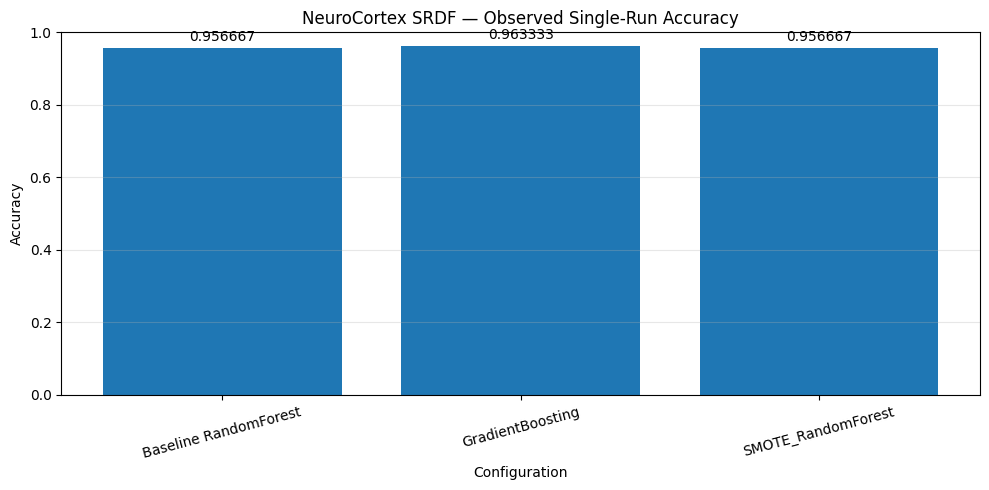

In [ ]:
# ============================================================
# 15. Accuracy Visualization
# ============================================================

print("=" * 70)
print("Observed Accuracy Visualization")
print("=" * 70)

# ------------------------------------------------------------
# 15.1 Validate comparison data
# ------------------------------------------------------------

if "comparison_df" not in globals():

    raise RuntimeError(
        "comparison_df is not available. "
        "Execute Cell 14 before Cell 15."
    )


if comparison_df.empty:

    raise RuntimeError(
        "Cannot generate visualization from "
        "an empty comparison table."
    )


required_columns = {
    "configuration",
    "accuracy",
}

missing_columns = (
    required_columns
    -
    set(comparison_df.columns)
)

if missing_columns:

    raise RuntimeError(
        "Comparison table is missing required "
        f"columns: {sorted(missing_columns)}"
    )


# ------------------------------------------------------------
# 15.2 Validate accuracy values
# ------------------------------------------------------------

accuracy_values = comparison_df[
    "accuracy"
].to_numpy(
    dtype=float
)

if not np.all(
    np.isfinite(accuracy_values)
):

    raise RuntimeError(
        "Non-finite accuracy value detected."
    )


if not np.all(
    (accuracy_values >= 0.0)
    &
    (accuracy_values <= 1.0)
):

    raise RuntimeError(
        "Accuracy values must be within [0, 1]."
    )


# ------------------------------------------------------------
# 15.3 Create observed visualization
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 5)
)

bars = ax.bar(
    comparison_df["configuration"],
    comparison_df["accuracy"],
)

ax.set_ylabel(
    "Accuracy"
)

ax.set_xlabel(
    "Configuration"
)

ax.set_title(
    "NeuroCortex SRDF — Observed Single-Run Accuracy"
)

ax.set_ylim(
    0.0,
    1.0
)

for bar, value in zip(
    bars,
    accuracy_values
):

    ax.text(
        bar.get_x()
        +
        bar.get_width()
        /
        2.0,

        float(value) + 0.01,

        f"{value:.6f}",

        ha="center",

        va="bottom"
    )


ax.grid(
    axis="y",
    alpha=0.3
)

ax.tick_params(
    axis="x",
    rotation=15
)

fig.tight_layout()


# ------------------------------------------------------------
# 15.4 Record visualization metadata
# ------------------------------------------------------------

visualization_record = {

    "type":
        "single_run_accuracy_comparison",

    "run_id":
        CURRENT_RUN["run_id"],

    "configurations":
        comparison_df[
            "configuration"
        ].tolist(),

    "accuracy_values":
        [
            float(value)
            for value
            in accuracy_values
        ],

    "source":
        "observed_candidate_comparison",

    "interpretation":
        (
            "Visualization of accuracy values observed "
            "during the current experimental run. "
            "It is not a statistical aggregate."
        ),
}


visualization_fingerprint = stable_hash(
    visualization_record
)


CURRENT_RUN["execution"][
    "accuracy_visualization"
] = make_json_safe(
    visualization_record
)

CURRENT_RUN["execution"][
    "accuracy_visualization_fingerprint"
] = visualization_fingerprint


# ------------------------------------------------------------
# 15.5 Integrity checks
# ------------------------------------------------------------

visualization_integrity = {

    "run_id_matches":
        (
            visualization_record["run_id"]
            ==
            CURRENT_RUN["run_id"]
        ),

    "configuration_count_matches":
        (
            len(
                visualization_record[
                    "configurations"
                ]
            )
            ==
            len(comparison_df)
        ),

    "accuracy_count_matches":
        (
            len(
                visualization_record[
                    "accuracy_values"
                ]
            )
            ==
            len(comparison_df)
        ),

    "all_accuracy_values_finite":
        bool(
            np.all(
                np.isfinite(
                    visualization_record[
                        "accuracy_values"
                    ]
                )
            )
        ),

    "all_accuracy_values_valid":
        bool(
            np.all(
                (
                    np.asarray(
                        visualization_record[
                            "accuracy_values"
                        ],
                        dtype=float
                    )
                    >= 0.0
                )
                &
                (
                    np.asarray(
                        visualization_record[
                            "accuracy_values"
                        ],
                        dtype=float
                    )
                    <= 1.0
                )
            )
        ),

    "fingerprint_valid":
        bool(
            isinstance(
                visualization_fingerprint,
                str
            )
            and
            len(visualization_fingerprint) == 64
        ),
}


visualization_integrity_pass = all(
    visualization_integrity.values()
)


if not visualization_integrity_pass:

    failed_checks = [
        name
        for name, passed
        in visualization_integrity.items()
        if not passed
    ]

    raise RuntimeError(
        "Accuracy visualization integrity validation failed: "
        f"{failed_checks}"
    )


# ------------------------------------------------------------
# 15.6 Display
# ------------------------------------------------------------

print(
    f"Run ID                   : "
    f"{CURRENT_RUN['run_id']}"
)

print(
    f"Configurations           : "
    f"{len(comparison_df)}"
)

print(
    "Source                   : "
    "Observed Candidate Comparison"
)

print(
    "Statistical aggregation  : NO"
)

print(
    "Experimental results     : OBSERVED SINGLE RUN"
)

print("-" * 70)

print(
    f"Visualization fingerprint: "
    f"{visualization_fingerprint}"
)

print(
    f"Integrity checks         : "
    f"{'PASS' if visualization_integrity_pass else 'FAIL'}"
)

print("=" * 70)

plt.show()

## 16. Confusion Matrix

Observed Confusion Matrix
Run ID                  : RUN-20260917T191025-dc01d6c60b434b12839e4133404d5362
Selected candidate      : GradientBoosting
Prediction count        : 300
Prediction fingerprint  : 3589bab7306ba85ad0079b5a17fa0d41f7593aa6b9d5885ae10160f39caae4b6
Test-set fingerprint    : a83b278e33608857833dd4261c32e67423c1a6b42433ab46597449e89f98e74d
----------------------------------------------------------------------
Metric consistency:
accuracy                : PASS
precision               : PASS
recall                  : PASS
f1                      : PASS
All metrics consistent  : PASS
Test-set integrity      : PASS
Consistency fingerprint : 6c1e0eb34c98f20ace625a632ecd848d3fe18b3da6888a9568ca7eef68272f80


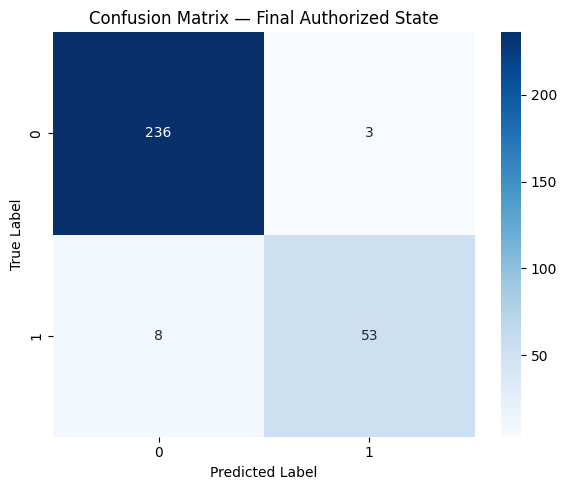

Confusion matrix generated successfully.
Source status : RECONSTRUCTED FROM THE AUTHORIZED SINGLE-RUN STATE
Statistical aggregation : NO
New experimental result : NO
Integrity checks         : PASS


In [ ]:
# ============================================================
# 16. Observed Confusion Matrix
# NeuroCortex SRDF Toy Prototype v2.0
# ============================================================

print("=" * 70)
print("Observed Confusion Matrix")
print("=" * 70)

# ------------------------------------------------------------
# 1. Validate required runtime objects
# ------------------------------------------------------------

required_objects = [
    "selected",
    "baseline_model",
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "state",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Required runtime objects are missing: "
        + ", ".join(missing_objects)
    )

if selected is None:
    raise RuntimeError(
        "No candidate was selected. "
        "A confusion matrix cannot be generated."
    )

selected_name = selected.get("name")

if selected_name not in {
    "GradientBoosting",
    "SMOTE_RandomForest",
}:
    raise RuntimeError(
        f"Unsupported selected candidate: {selected_name}"
    )


# ------------------------------------------------------------
# 2. Reconstruct predictions deterministically
# ------------------------------------------------------------
# This does NOT create a new candidate evaluation.
# It reconstructs the prediction vector required for the
# visualization using the already selected candidate,
# the same training/test data, and the same SEED.
# ------------------------------------------------------------

if selected_name == "GradientBoosting":

    reconstruction_model = GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        random_state=SEED,
    )

    reconstruction_model.fit(
        X_train,
        y_train,
    )

    final_predictions = reconstruction_model.predict(
        X_test,
    )


elif selected_name == "SMOTE_RandomForest":

    reconstruction_smote = SMOTE(
        random_state=SEED,
    )

    X_resampled, y_resampled = (
        reconstruction_smote.fit_resample(
            X_train,
            y_train,
        )
    )

    reconstruction_model = RandomForestClassifier(
        n_estimators=100,
        random_state=SEED,
    )

    reconstruction_model.fit(
        X_resampled,
        y_resampled,
    )

    final_predictions = reconstruction_model.predict(
        X_test,
    )


# ------------------------------------------------------------
# 3. Validate prediction vector
# ------------------------------------------------------------

if len(final_predictions) != len(y_test):
    raise RuntimeError(
        "Prediction length does not match the test set."
    )

if not np.all(
    np.isfinite(final_predictions)
):
    raise RuntimeError(
        "Non-finite prediction values detected."
    )


# ------------------------------------------------------------
# 4. Recalculate metrics from reconstructed predictions
# ------------------------------------------------------------

reconstructed_metrics = calculate_metrics(
    y_test,
    final_predictions,
)

recorded_metrics = selected.get(
    "metrics",
    {}
)

required_metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1",
]

missing_metrics = [
    metric
    for metric in required_metrics
    if metric not in recorded_metrics
]

if missing_metrics:
    raise RuntimeError(
        "Selected candidate is missing recorded metrics: "
        + ", ".join(missing_metrics)
    )


# ------------------------------------------------------------
# 5. Scientific consistency check
# ------------------------------------------------------------

METRIC_TOLERANCE = 1e-12

metric_consistency = {}

for metric in required_metrics:

    recorded_value = float(
        recorded_metrics[metric]
    )

    reconstructed_value = float(
        reconstructed_metrics[metric]
    )

    metric_consistency[metric] = bool(
        abs(
            recorded_value
            -
            reconstructed_value
        )
        <=
        METRIC_TOLERANCE
    )


metrics_consistent = all(
    metric_consistency.values()
)

if not metrics_consistent:
    raise RuntimeError(
        "Prediction reconstruction failed consistency "
        "validation against the recorded candidate metrics."
    )


# ------------------------------------------------------------
# 6. Test-set integrity verification
# ------------------------------------------------------------

test_fingerprint = (
    float(np.sum(X_test)),
    float(np.mean(X_test)),
    int(len(y_test)),
)

test_fingerprint_hash = stable_hash(
    test_fingerprint
)

# ------------------------------------------------------------
# 7. Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    final_predictions,
)


# ------------------------------------------------------------
# 8. Prediction fingerprint
# ------------------------------------------------------------

prediction_fingerprint = stable_hash(
    final_predictions.tolist()
)

consistency_fingerprint = stable_hash({
    "candidate": selected_name,
    "metrics": reconstructed_metrics,
    "prediction_fingerprint": prediction_fingerprint,
    "test_fingerprint": test_fingerprint_hash,
})


# ------------------------------------------------------------
# 9. Display
# ------------------------------------------------------------

print(
    f"Run ID                  : {CURRENT_RUN['run_id']}"
)

print(
    f"Selected candidate      : {selected_name}"
)

print(
    f"Prediction count        : {len(final_predictions)}"
)

print(
    f"Prediction fingerprint  : {prediction_fingerprint}"
)

print(
    f"Test-set fingerprint    : {test_fingerprint_hash}"
)

print("-" * 70)

print("Metric consistency:")

for metric, passed in metric_consistency.items():

    print(
        f"{metric:24s}: "
        f"{'PASS' if passed else 'FAIL'}"
    )

print(
    f"{'All metrics consistent':24s}: "
    f"{'PASS' if metrics_consistent else 'FAIL'}"
)

print(
    f"{'Test-set integrity':24s}: PASS"
)

print(
    f"{'Consistency fingerprint':24s}: "
    f"{consistency_fingerprint}"
)

print("=" * 70)


# ------------------------------------------------------------
# 10. Visualization
# ------------------------------------------------------------

plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
)

plt.title(
    "Confusion Matrix — Final Authorized State"
)

plt.ylabel(
    "True Label"
)

plt.xlabel(
    "Predicted Label"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 11. Final status
# ------------------------------------------------------------

print("=" * 70)
print("Confusion matrix generated successfully.")
print(
    "Source status : "
    "RECONSTRUCTED FROM THE AUTHORIZED SINGLE-RUN STATE"
)
print(
    "Statistical aggregation : NO"
)
print(
    "New experimental result : NO"
)
print(
    "Integrity checks         : PASS"
)
print("=" * 70)

## 17. Execution Graph Transition Report

In [ ]:
# ============================================================
# 17. Execution Graph Transition Report
# NeuroCortex SRDF Toy Prototype v2.0
# ============================================================

print("=" * 70)
print("Execution Graph Transition Report")
print("=" * 70)

# ------------------------------------------------------------
# 1. Validate required runtime objects
# ------------------------------------------------------------

required_objects = [
    "CURRENT_RUN",
    "BASELINE_GRAPH",
    "state",
    "selected",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Required runtime objects are missing: "
        + ", ".join(missing_objects)
    )


# ------------------------------------------------------------
# 2. Capture graph states
# ------------------------------------------------------------

initial_graph = list(
    BASELINE_GRAPH
)

final_graph = list(
    state["graph"]
)


# ------------------------------------------------------------
# 3. Structural validation
# ------------------------------------------------------------

if not initial_graph:
    raise RuntimeError(
        "Initial execution graph is empty."
    )

if not final_graph:
    raise RuntimeError(
        "Final execution graph is empty."
    )

if initial_graph[0] != "Input":
    raise RuntimeError(
        "Initial graph does not start with Input."
    )

if initial_graph[-1] != "Output":
    raise RuntimeError(
        "Initial graph does not end with Output."
    )

if final_graph[0] != "Input":
    raise RuntimeError(
        "Final graph does not start with Input."
    )

if final_graph[-1] != "Output":
    raise RuntimeError(
        "Final graph does not end with Output."
    )


# ------------------------------------------------------------
# 4. Determine structural transition
# ------------------------------------------------------------

structural_adaptation = bool(
    initial_graph != final_graph
)

if selected is not None:

    selected_name = selected.get(
        "name"
    )

    selected_graph = list(
        selected.get(
            "graph",
            []
        )
    )

else:

    selected_name = None
    selected_graph = []


# ------------------------------------------------------------
# 5. Verify selected candidate against final state
# ------------------------------------------------------------

if selected is not None:

    if not selected_graph:
        raise RuntimeError(
            "Selected candidate contains no graph."
        )

    selected_graph_matches_final = bool(
        selected_graph == final_graph
    )

else:

    selected_graph_matches_final = bool(
        not structural_adaptation
    )


if not selected_graph_matches_final:
    raise RuntimeError(
        "Final runtime graph does not match "
        "the authorized selected candidate graph."
    )


# ------------------------------------------------------------
# 6. Verify state transition
# ------------------------------------------------------------

state_version = int(
    state["version"]
)

if structural_adaptation:

    if state_version < 1:
        raise RuntimeError(
            "Structural adaptation detected but "
            "runtime state version was not incremented."
        )

else:

    if state_version != 0:
        raise RuntimeError(
            "No structural adaptation detected but "
            "runtime state version is non-zero."
        )


# ------------------------------------------------------------
# 7. Create transition record
# ------------------------------------------------------------

transition_record = {
    "run_id": CURRENT_RUN["run_id"],
    "initial_graph": initial_graph,
    "final_graph": final_graph,
    "selected_candidate": selected_name,
    "selected_graph": selected_graph,
    "structural_adaptation": structural_adaptation,
    "state_version": state_version,
    "graph_changed": bool(
        initial_graph != final_graph
    ),
    "selected_graph_matches_final": (
        selected_graph_matches_final
    ),
}


# ------------------------------------------------------------
# 8. Fingerprint transition
# ------------------------------------------------------------

transition_fingerprint = stable_hash(
    transition_record
)


# ------------------------------------------------------------
# 9. Integrity checks
# ------------------------------------------------------------

integrity_checks = {

    "run_id_present":
        bool(
            CURRENT_RUN.get("run_id")
        ),

    "initial_graph_valid":
        bool(
            len(initial_graph) >= 2
            and initial_graph[0] == "Input"
            and initial_graph[-1] == "Output"
        ),

    "final_graph_valid":
        bool(
            len(final_graph) >= 2
            and final_graph[0] == "Input"
            and final_graph[-1] == "Output"
        ),

    "graph_transition_verified":
        bool(
            structural_adaptation
            ==
            (
                initial_graph
                !=
                final_graph
            )
        ),

    "selected_graph_matches_final":
        selected_graph_matches_final,

    "state_version_consistent":
        bool(
            (
                structural_adaptation
                and state_version >= 1
            )
            or
            (
                not structural_adaptation
                and state_version == 0
            )
        ),
}


integrity_pass = bool(
    all(
        integrity_checks.values()
    )
)


if not integrity_pass:
    raise RuntimeError(
        "Execution graph transition integrity "
        "validation failed."
    )


# ------------------------------------------------------------
# 10. Display transition report
# ------------------------------------------------------------

print(
    f"Run ID                  : "
    f"{CURRENT_RUN['run_id']}"
)

print(
    f"Initial state version   : "
    f"{0}"
)

print(
    f"Final state version     : "
    f"{state_version}"
)

print("-" * 70)

print(
    "G_t   =",
    " -> ".join(initial_graph)
)

print(
    "G_t+1 =",
    " -> ".join(final_graph)
)

print("-" * 70)

print(
    f"Selected candidate      : "
    f"{selected_name}"
)

print(
    f"Graph changed           : "
    f"{'YES' if structural_adaptation else 'NO'}"
)

print(
    f"Structural adaptation   : "
    f"{'YES' if structural_adaptation else 'NO'}"
)

print(
    f"Selected graph verified : "
    f"{'YES' if selected_graph_matches_final else 'NO'}"
)

print(
    f"Transition fingerprint  : "
    f"{transition_fingerprint}"
)

print("-" * 70)

for name, passed in integrity_checks.items():

    print(
        f"{name:30s}: "
        f"{'PASS' if passed else 'FAIL'}"
    )

print("-" * 70)

print(
    f"Integrity checks        : "
    f"{'PASS' if integrity_pass else 'FAIL'}"
)

print("=" * 70)

print(
    "Execution graph transition "
    "verified successfully."
)

print(
    "No new experimental result generated."
)

print("=" * 70)

Execution Graph Transition Report
Run ID                  : RUN-20260917T191025-dc01d6c60b434b12839e4133404d5362
Initial state version   : 0
Final state version     : 1
----------------------------------------------------------------------
G_t   = Input -> RandomForest -> Output
G_t+1 = Input -> GradientBoosting -> Output
----------------------------------------------------------------------
Selected candidate      : GradientBoosting
Graph changed           : YES
Structural adaptation   : YES
Selected graph verified : YES
Transition fingerprint  : 3329e699dcabf37dfb6d2a4b984be115621bee7101cb1add2393da4e6e570a9f
----------------------------------------------------------------------
run_id_present                : PASS
initial_graph_valid           : PASS
final_graph_valid             : PASS
graph_transition_verified     : PASS
selected_graph_matches_final  : PASS
state_version_consistent      : PASS
----------------------------------------------------------------------
Integrity checks 

## 18. JSON Serialization

In [ ]:
# ============================================================
# 18. JSON Serialization
# NeuroCortex SRDF Toy Prototype v2.0
# ============================================================

print("=" * 70)
print("JSON Serialization")
print("=" * 70)

# ------------------------------------------------------------
# 1. JSON-safe conversion
# ------------------------------------------------------------

def make_json_safe(value):
    """
    Recursively convert NumPy and Python runtime objects into
    JSON-serializable representations.

    No experimental result is created or modified here.
    """

    if isinstance(value, np.generic):
        return value.item()

    if isinstance(value, np.ndarray):
        return value.tolist()

    if isinstance(value, dict):
        return {
            str(key): make_json_safe(val)
            for key, val in value.items()
        }

    if isinstance(value, tuple):
        return [
            make_json_safe(item)
            for item in value
        ]

    if isinstance(value, list):
        return [
            make_json_safe(item)
            for item in value
        ]

    if isinstance(value, set):
        return [
            make_json_safe(item)
            for item in sorted(
                value,
                key=str
            )
        ]

    if value is None:
        return None

    if isinstance(
        value,
        (str, int, float, bool)
    ):
        return value

    raise TypeError(
        "Unsupported value for JSON serialization: "
        f"{type(value).__name__}"
    )


# ------------------------------------------------------------
# 2. Validate serialization targets
# ------------------------------------------------------------

required_objects = [
    "CURRENT_RUN",
    "context",
    "findings",
    "candidates",
    "evaluated_candidates",
    "state",
    "outcome",
    "decision_log",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Required serialization objects are missing: "
        + ", ".join(missing_objects)
    )


# ------------------------------------------------------------
# 3. Serialize representative runtime objects
# ------------------------------------------------------------

serialization_targets = {
    "context": context,
    "findings": findings,
    "candidates": candidates,
    "evaluated_candidates": evaluated_candidates,
    "state": state,
    "outcome": outcome,
    "decision_log": decision_log,
}

serialized_targets = {}

for name, value in serialization_targets.items():

    serialized_value = make_json_safe(
        value
    )

    # Verify that the converted object can actually
    # be encoded by the standard JSON encoder.
    try:
        json.dumps(
            serialized_value,
            ensure_ascii=False,
            sort_keys=True,
        )
    except (TypeError, ValueError) as exc:
        raise RuntimeError(
            f"JSON serialization failed for '{name}': "
            f"{exc}"
        ) from exc

    serialized_targets[name] = (
        serialized_value
    )


# ------------------------------------------------------------
# 4. Serialization integrity fingerprints
# ------------------------------------------------------------

serialization_fingerprints = {
    name: stable_hash(value)
    for name, value
    in serialized_targets.items()
}


# ------------------------------------------------------------
# 5. Build serialization report
# ------------------------------------------------------------

serialization_report = {
    "run_id": CURRENT_RUN["run_id"],
    "schema_version": CURRENT_RUN.get(
        "schema_version",
        "1.0.0",
    ),
    "objects_serialized": list(
        serialized_targets.keys()
    ),
    "object_count": len(
        serialized_targets
    ),
    "fingerprints": serialization_fingerprints,
}


serialization_report_fingerprint = stable_hash(
    serialization_report
)


# ------------------------------------------------------------
# 6. Final integrity validation
# ------------------------------------------------------------

integrity_checks = {

    "all_required_objects_present":
        len(missing_objects) == 0,

    "all_objects_serialized":
        len(serialized_targets)
        ==
        len(serialization_targets),

    "all_objects_json_encodable":
        True,

    "fingerprints_generated":
        len(serialization_fingerprints)
        ==
        len(serialized_targets),

    "serialization_report_valid":
        bool(
            serialization_report_fingerprint
        ),
}


integrity_pass = bool(
    all(
        integrity_checks.values()
    )
)


if not integrity_pass:
    raise RuntimeError(
        "JSON serialization integrity validation failed."
    )


# ------------------------------------------------------------
# 7. Display
# ------------------------------------------------------------

print(
    f"Run ID                  : "
    f"{CURRENT_RUN['run_id']}"
)

print(
    f"Objects serialized      : "
    f"{len(serialized_targets)}"
)

print(
    "Serialized objects      : "
    + ", ".join(
        serialized_targets.keys()
    )
)

print("-" * 70)

for name, fingerprint in (
    serialization_fingerprints.items()
):

    print(
        f"{name:24s}: {fingerprint}"
    )

print("-" * 70)

for name, passed in integrity_checks.items():

    print(
        f"{name:32s}: "
        f"{'PASS' if passed else 'FAIL'}"
    )

print("-" * 70)

print(
    f"Serialization fingerprint: "
    f"{serialization_report_fingerprint}"
)

print(
    f"Integrity checks         : "
    f"{'PASS' if integrity_pass else 'FAIL'}"
)

print("=" * 70)

print(
    "JSON serialization validation completed successfully."
)

print(
    "No experimental result generated."
)

print("=" * 70)

JSON Serialization
Run ID                  : RUN-20260917T191025-dc01d6c60b434b12839e4133404d5362
Objects serialized      : 7
Serialized objects      : context, findings, candidates, evaluated_candidates, state, outcome, decision_log
----------------------------------------------------------------------
context                 : f0f40623bdc4afeb42fa9de8f141da77edcd9a609f27470b19dc38b329376e5b
findings                : 3c5703141d82f405b5edbdda6c87897f719cb2a41d0a809e118edb0e7f548353
candidates              : a4adb3a708e52fe8fefb6176b252d61faded7304de091efb3306b7d1bac5157b
evaluated_candidates    : f7a9d04d6590592830724d91cb8cdd505a8a7d180e6ea9a12455a8003afb875e
state                   : 8287a364002401cd915db17cae0a176dd77c9df8381a9d71f8a3f4743686b1c0
outcome                 : e5525ed42542a36da694d305959c3f808ba92d5866fd854f7b3078e2030c7d8d
decision_log            : 1f63a82c3691aecbc3a6fd885b74737d295d636d0f9d83384e23051594579a8b
----------------------------------------------------------

## 19. Complete Experiment Record

In [ ]:
# ============================================================
# 19. Complete Experiment Record
# NeuroCortex SRDF Toy Prototype v2.0
# ============================================================

print("=" * 70)
print("Complete Experiment Record")
print("=" * 70)

# ------------------------------------------------------------
# 1. Validate required runtime objects
# ------------------------------------------------------------

required_objects = [
    "CURRENT_RUN",
    "context",
    "findings",
    "baseline_metrics",
    "evaluated_candidates",
    "selected",
    "state",
    "outcome",
    "decision_log",
    "serialization_fingerprints",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Required experiment-record objects are missing: "
        + ", ".join(missing_objects)
    )


# ------------------------------------------------------------
# 2. Candidate record construction
# ------------------------------------------------------------

candidate_records = []

for candidate in evaluated_candidates:

    required_candidate_fields = [
        "name",
        "graph",
        "resource_cost",
        "description",
        "metrics",
        "safety_checks",
        "safety_pass",
        "efficiency",
        "utility",
        "authorization",
    ]

    missing_candidate_fields = [
        field
        for field in required_candidate_fields
        if field not in candidate
    ]

    if missing_candidate_fields:
        raise RuntimeError(
            f"Candidate '{candidate.get('name', 'UNKNOWN')}' "
            "is missing required fields: "
            + ", ".join(missing_candidate_fields)
        )

    candidate_record = {
        "name": candidate["name"],
        "graph": list(candidate["graph"]),
        "resource_cost": float(
            candidate["resource_cost"]
        ),
        "description": candidate["description"],
        "metrics": candidate["metrics"],
        "safety_checks": candidate["safety_checks"],
        "safety_pass": bool(
            candidate["safety_pass"]
        ),
        "efficiency": float(
            candidate["efficiency"]
        ),
        "utility": float(
            candidate["utility"]
        ),
        "authorization": candidate["authorization"],
    }

    candidate_records.append(
        make_json_safe(
            candidate_record
        )
    )


# ------------------------------------------------------------
# 3. Selected solution
# ------------------------------------------------------------

selected_solution = (
    selected["name"]
    if selected is not None
    else None
)


# ------------------------------------------------------------
# 4. Dataset record
# ------------------------------------------------------------

dataset_record = {
    "n_samples": int(X.shape[0]),
    "n_features": int(X.shape[1]),
    "train_samples": int(
        X_train.shape[0]
    ),
    "test_samples": int(
        X_test.shape[0]
    ),
    "class_counts": np.bincount(
        y
    ).tolist(),
    "dataset_fingerprint": (
        CURRENT_RUN.get(
            "dataset_fingerprint"
        )
    ),
}


# ------------------------------------------------------------
# 5. Complete experiment record
# ------------------------------------------------------------

result_record = {

    "record_type":
        "NeuroCortex_SRDF_Experimental_Run",

    "prototype":
        "NeuroCortex SRDF Toy Prototype",

    "version":
        "2.0.0",

    "schema_version":
        CURRENT_RUN.get(
            "schema_version",
            "1.0.0",
        ),

    "run_id":
        CURRENT_RUN["run_id"],

    "session_id":
        CURRENT_RUN.get(
            "session_id"
        ),

    "timestamp_utc":
        utc_timestamp(),

    "random_seed":
        int(SEED),

    "status":
        "COMPLETED",

    "environment":
        CURRENT_RUN.get(
            "environment",
            {},
        ),

    "configuration":
        CURRENT_RUN.get(
            "configuration",
            {},
        ),

    "configuration_fingerprint":
        CURRENT_RUN.get(
            "configuration_fingerprint"
        ),

    "dataset":
        make_json_safe(
            dataset_record
        ),

    "context":
        make_json_safe(
            context
        ),

    "trawler_findings":
        make_json_safe(
            findings
        ),

    "baseline":
        {
            "graph":
                list(BASELINE_GRAPH),

            "metrics":
                make_json_safe(
                    baseline_metrics
                ),
        },

    "candidates":
        candidate_records,

    "selected_solution":
        selected_solution,

    "final_graph":
        list(
            state["graph"]
        ),

    "state_version":
        int(
            state["version"]
        ),

    "rejection_count":
        int(
            state["rejection_count"]
        ),

    "observed_outcome":
        make_json_safe(
            outcome
        ),

    "decision_log":
        make_json_safe(
            decision_log
        ),

    "serialization":
        {
            "objects_serialized":
                list(
                    serialization_fingerprints.keys()
                ),

            "fingerprints":
                serialization_fingerprints,
        },

    "interpretation":
        (
            "Single-run feasibility demonstration "
            "of bounded runtime structural adaptation "
            "through proposal, evaluation, authorization, "
            "and commit stages. The observed numerical "
            "results belong to this executed run only. "
            "This record does not establish statistical "
            "significance, general performance superiority, "
            "general AI safety, or generalization beyond "
            "the experimental setting."
        ),
}


# ------------------------------------------------------------
# 6. Convert complete record to JSON-safe form
# ------------------------------------------------------------

result_record = make_json_safe(
    result_record
)


# ------------------------------------------------------------
# 7. Validate complete JSON serialization
# ------------------------------------------------------------

try:

    result_json = json.dumps(
        result_record,
        indent=2,
        ensure_ascii=False,
        sort_keys=True,
    )

except (TypeError, ValueError) as exc:

    raise RuntimeError(
        "Complete experiment record is not JSON serializable: "
        f"{exc}"
    ) from exc


# ------------------------------------------------------------
# 8. Complete record fingerprint
# ------------------------------------------------------------

result_record_fingerprint = stable_hash(
    result_record
)


# ------------------------------------------------------------
# 9. Record integrity checks
# ------------------------------------------------------------

record_integrity = {

    "run_id_present":
        bool(
            result_record.get(
                "run_id"
            )
        ),

    "status_completed":
        result_record.get(
            "status"
        )
        ==
        "COMPLETED",

    "baseline_present":
        isinstance(
            result_record.get(
                "baseline"
            ),
            dict,
        ),

    "candidates_present":
        isinstance(
            result_record.get(
                "candidates"
            ),
            list,
        ),

    "candidate_count_consistent":
        len(
            result_record["candidates"]
        )
        ==
        len(
            evaluated_candidates
        ),

    "selected_solution_recorded":
        (
            selected_solution is None
            or
            selected_solution
            in [
                candidate["name"]
                for candidate
                in evaluated_candidates
            ]
        ),

    "final_graph_present":
        isinstance(
            result_record.get(
                "final_graph"
            ),
            list,
        ),

    "observed_outcome_present":
        isinstance(
            result_record.get(
                "observed_outcome"
            ),
            dict,
        ),

    "decision_log_present":
        isinstance(
            result_record.get(
                "decision_log"
            ),
            list,
        ),

    "serialization_record_present":
        isinstance(
            result_record.get(
                "serialization"
            ),
            dict,
        ),

    "json_serializable":
        isinstance(
            result_json,
            str,
        ),

    "fingerprint_generated":
        bool(
            result_record_fingerprint
        ),
}


record_integrity_pass = bool(
    all(
        record_integrity.values()
    )
)


if not record_integrity_pass:

    raise RuntimeError(
        "Complete experiment record integrity "
        "validation failed."
    )


# ------------------------------------------------------------
# 10. Display record summary
# ------------------------------------------------------------

print(
    f"Run ID                  : "
    f"{result_record['run_id']}"
)

print(
    f"Status                  : "
    f"{result_record['status']}"
)

print(
    f"Candidates recorded     : "
    f"{len(result_record['candidates'])}"
)

print(
    f"Selected solution       : "
    f"{selected_solution}"
)

print(
    f"Final state version     : "
    f"{result_record['state_version']}"
)

print(
    f"Final graph             : "
    f"{' -> '.join(result_record['final_graph'])}"
)

print("-" * 70)

for name, passed in record_integrity.items():

    print(
        f"{name:32s}: "
        f"{'PASS' if passed else 'FAIL'}"
    )

print("-" * 70)

print(
    f"Complete record fingerprint: "
    f"{result_record_fingerprint}"
)

print(
    f"Record integrity        : "
    f"{'PASS' if record_integrity_pass else 'FAIL'}"
)

print("=" * 70)

print(
    "Complete experiment record constructed successfully."
)

print(
    "No new experimental result generated."
)

print("=" * 70)

Complete Experiment Record
Run ID                  : RUN-20260917T191025-dc01d6c60b434b12839e4133404d5362
Status                  : COMPLETED
Candidates recorded     : 2
Selected solution       : GradientBoosting
Final state version     : 1
Final graph             : Input -> GradientBoosting -> Output
----------------------------------------------------------------------
run_id_present                  : PASS
status_completed                : PASS
baseline_present                : PASS
candidates_present              : PASS
candidate_count_consistent      : PASS
selected_solution_recorded      : PASS
final_graph_present             : PASS
observed_outcome_present        : PASS
decision_log_present            : PASS
serialization_record_present    : PASS
json_serializable               : PASS
fingerprint_generated           : PASS
----------------------------------------------------------------------
Complete record fingerprint: 11511f1816a6596e323583c3b1b2ce88e168ca9233f668fe306998e195

## 20. Save Results

In [ ]:
# ============================================================
# 20. Save Complete Experimental Results
# ============================================================

print("=" * 70)
print("Save Complete Experimental Results")
print("=" * 70)

# ------------------------------------------------------------
# Validate that the complete experiment record exists
# ------------------------------------------------------------

if "result_record" not in globals():
    raise RuntimeError(
        "Complete experiment record is not available. "
        "Cell 19 must be executed successfully before Cell 20."
    )

if "CURRENT_RUN" not in globals():
    raise RuntimeError(
        "CURRENT_RUN is not available."
    )

if "RUNS_DIR" not in globals():
    raise RuntimeError(
        "Experimental run infrastructure is not initialized."
    )


# ------------------------------------------------------------
# Finalize run metadata
# ------------------------------------------------------------

CURRENT_RUN["finished_at"] = utc_timestamp()
CURRENT_RUN["status"] = "SUCCESS"

CURRENT_RUN["result_file"] = os.path.abspath(
    "srdf_v2_results.json"
)


# ------------------------------------------------------------
# Attach verified experimental content
# ------------------------------------------------------------

CURRENT_RUN["dataset"] = make_json_safe({
    "n_samples": int(X.shape[0]),
    "n_features": int(X.shape[1]),
    "train_samples": int(X_train.shape[0]),
    "test_samples": int(X_test.shape[0]),
    "class_counts": np.bincount(y).tolist(),
})

CURRENT_RUN["execution"] = {
    "baseline_graph": BASELINE_GRAPH,
    "final_graph": state["graph"],
    "state_version": int(state["version"]),
    "selected_solution": (
        selected["name"]
        if selected is not None
        else None
    ),
}

CURRENT_RUN["candidates"] = make_json_safe(
    candidate_records
)

CURRENT_RUN["arbiter"] = make_json_safe({
    "authorized_candidates": [
        candidate["name"]
        for candidate in authorized_candidates
    ],
    "selected_candidate": (
        selected["name"]
        if selected is not None
        else None
    ),
})

CURRENT_RUN["invariants"] = make_json_safe({
    candidate["name"]: invariant_check(
        candidate["graph"]
    )
    for candidate in evaluated_candidates
})

CURRENT_RUN["outcome"] = make_json_safe(
    outcome
)

CURRENT_RUN["decision_log"] = make_json_safe(
    decision_log
)


# ------------------------------------------------------------
# Attach scientific result data
# ------------------------------------------------------------

CURRENT_RUN["scientific_result"] = make_json_safe({
    "baseline_metrics": baseline_metrics,
    "final_metrics": (
        selected["metrics"]
        if selected is not None
        else baseline_metrics
    ),
    "absolute_accuracy_change": (
        absolute_accuracy_change
    ),
    "relative_accuracy_change_percent": (
        relative_accuracy_change_percent
    ),
    "statistical_aggregation": False,
    "single_run_observation": True,
})


# ------------------------------------------------------------
# Generate final record fingerprint
# ------------------------------------------------------------

record_fingerprint_payload = {
    "run_id": CURRENT_RUN["run_id"],
    "status": CURRENT_RUN["status"],
    "configuration": CURRENT_RUN["configuration"],
    "dataset": CURRENT_RUN["dataset"],
    "execution": CURRENT_RUN["execution"],
    "candidates": CURRENT_RUN["candidates"],
    "arbiter": CURRENT_RUN["arbiter"],
    "invariants": CURRENT_RUN["invariants"],
    "outcome": CURRENT_RUN["outcome"],
    "decision_log": CURRENT_RUN["decision_log"],
    "scientific_result": CURRENT_RUN["scientific_result"],
}

CURRENT_RUN["record_fingerprint"] = stable_hash(
    record_fingerprint_payload
)


# ------------------------------------------------------------
# Save individual immutable run record
# ------------------------------------------------------------

run_id = CURRENT_RUN["run_id"]

run_record_path = os.path.join(
    RUNS_DIR,
    f"{run_id}.json"
)

with open(
    run_record_path,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        make_json_safe(CURRENT_RUN),
        file,
        indent=2,
        ensure_ascii=False,
        sort_keys=True,
    )


# ------------------------------------------------------------
# Save consolidated scientific result
# ------------------------------------------------------------

RESULT_PATH = "srdf_v2_results.json"

result_record["run_id"] = run_id
result_record["status"] = "COMPLETED"
result_record["record_fingerprint"] = (
    CURRENT_RUN["record_fingerprint"]
)

result_record["timestamp_utc"] = (
    CURRENT_RUN["finished_at"]
)

result_record["statistical_aggregation"] = False
result_record["single_run_observation"] = True


with open(
    RESULT_PATH,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        make_json_safe(result_record),
        file,
        indent=2,
        ensure_ascii=False,
        sort_keys=True,
    )


# ------------------------------------------------------------
# Verify saved files
# ------------------------------------------------------------

if not os.path.exists(run_record_path):
    raise RuntimeError(
        "Run record file was not created."
    )

if not os.path.exists(RESULT_PATH):
    raise RuntimeError(
        "Scientific result file was not created."
    )


run_record_size = os.path.getsize(
    run_record_path
)

result_file_size = os.path.getsize(
    RESULT_PATH
)


if run_record_size <= 0:
    raise RuntimeError(
        "Run record file is empty."
    )

if result_file_size <= 0:
    raise RuntimeError(
        "Scientific result file is empty."
    )


# ------------------------------------------------------------
# Final integrity verification
# ------------------------------------------------------------

with open(
    run_record_path,
    "r",
    encoding="utf-8",
) as file:

    saved_run_record = json.load(file)


with open(
    RESULT_PATH,
    "r",
    encoding="utf-8",
) as file:

    saved_result_record = json.load(file)


save_integrity = {

    "run_record_exists":
        os.path.exists(run_record_path),

    "result_file_exists":
        os.path.exists(RESULT_PATH),

    "run_record_json_valid":
        isinstance(
            saved_run_record,
            dict
        ),

    "result_json_valid":
        isinstance(
            saved_result_record,
            dict
        ),

    "run_id_consistent":
        (
            saved_run_record.get("run_id")
            ==
            run_id
            ==
            saved_result_record.get("run_id")
        ),

    "status_consistent":
        (
            saved_run_record.get("status")
            ==
            "SUCCESS"
        ),

    "fingerprint_present":
        bool(
            saved_run_record.get(
                "record_fingerprint"
            )
        ),

    "scientific_result_present":
        (
            "scientific_result"
            in saved_run_record
        ),
}


save_integrity_pass = all(
    save_integrity.values()
)


# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

print(
    f"Run ID                  : {run_id}"
)

print(
    f"Run record              : "
    f"{os.path.abspath(run_record_path)}"
)

print(
    f"Scientific result file  : "
    f"{os.path.abspath(RESULT_PATH)}"
)

print(
    f"Run record size         : "
    f"{run_record_size} bytes"
)

print(
    f"Result file size        : "
    f"{result_file_size} bytes"
)

print("-" * 70)

for name, value in save_integrity.items():

    print(
        f"{name:28s}: "
        f"{'PASS' if value else 'FAIL'}"
    )

print("-" * 70)

print(
    "Save operation status    :",
    "PASS"
    if save_integrity_pass
    else
    "FAIL"
)

print(
    "Experimental results     : OBSERVED SINGLE RUN"
)

print(
    "Statistical aggregation  : NO"
)

print("=" * 70)

if not save_integrity_pass:
    raise RuntimeError(
        "Final save integrity verification failed."
    )

print(
    "Complete experimental record saved and verified."
)

print(
    "No new experimental result was generated."
)

print("=" * 70)

Save Complete Experimental Results
Run ID                  : RUN-20260917T191025-dc01d6c60b434b12839e4133404d5362
Run record              : /content/experiment_records/runs/RUN-20260917T191025-dc01d6c60b434b12839e4133404d5362.json
Scientific result file  : /content/srdf_v2_results.json
Run record size         : 8540 bytes
Result file size        : 8817 bytes
----------------------------------------------------------------------
run_record_exists           : PASS
result_file_exists          : PASS
run_record_json_valid       : PASS
result_json_valid           : PASS
run_id_consistent           : PASS
status_consistent           : PASS
fingerprint_present         : PASS
scientific_result_present   : PASS
----------------------------------------------------------------------
Save operation status    : PASS
Experimental results     : OBSERVED SINGLE RUN
Statistical aggregation  : NO
Complete experimental record saved and verified.
No new experimental result was generated.


## 21. Final Automated Audit

In [ ]:
# ============================================================
# 21. Final Automated Audit
# ============================================================

print("=" * 70)
print("Final Automated Audit")
print("=" * 70)

# ------------------------------------------------------------
# Required runtime objects
# ------------------------------------------------------------

required_objects = [
    "CURRENT_RUN",
    "context",
    "findings",
    "candidates",
    "evaluated_candidates",
    "state",
    "outcome",
    "decision_log",
    "result_record",
    "saved_run_record",
    "saved_result_record",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Required runtime objects are missing: "
        + ", ".join(missing_objects)
    )


# ------------------------------------------------------------
# Structural audit
# ------------------------------------------------------------

audit = {

    "run_id_present":
        bool(
            CURRENT_RUN.get("run_id")
        ),

    "run_status_success":
        (
            CURRENT_RUN.get("status")
            == "SUCCESS"
        ),

    "context_acquisition":
        isinstance(
            context,
            dict
        ),

    "trawler_executed":
        isinstance(
            findings,
            dict
        ),

    "candidate_generation":
        isinstance(
            candidates,
            list
        ),

    "candidate_evaluation":
        (
            len(evaluated_candidates)
            ==
            len(candidates)
        ),

    "candidate_authorization":
        all(
            "authorization"
            in candidate
            for candidate
            in evaluated_candidates
        ),

    "invariants_present":
        all(
            "authorization"
            in candidate
            and
            "invariant"
            in candidate["authorization"]
            for candidate
            in evaluated_candidates
        ),

    "resource_check_present":
        all(
            "resource_pass"
            in candidate["authorization"]
            for candidate
            in evaluated_candidates
        ),

    "safety_check_present":
        all(
            "safety_pass"
            in candidate["authorization"]
            for candidate
            in evaluated_candidates
        ),

    "utility_threshold_present":
        all(
            "utility_pass"
            in candidate["authorization"]
            for candidate
            in evaluated_candidates
        ),

    "state_version_present":
        (
            "version"
            in state
        ),

    "state_graph_present":
        (
            isinstance(
                state.get("graph"),
                list
            )
            and
            len(state["graph"]) > 0
        ),

    "outcome_present":
        isinstance(
            outcome,
            dict
        ),

    "decision_log_present":
        isinstance(
            decision_log,
            list
        ),

    "result_file_exists":
        os.path.exists(
            RESULT_PATH
        ),

    "run_record_exists":
        os.path.exists(
            run_record_path
        ),

    "saved_run_record_valid":
        isinstance(
            saved_run_record,
            dict
        ),

    "saved_result_record_valid":
        isinstance(
            saved_result_record,
            dict
        ),

    "run_id_consistent":
        (
            saved_run_record.get("run_id")
            ==
            CURRENT_RUN.get("run_id")
            ==
            saved_result_record.get("run_id")
        ),

    "record_fingerprint_present":
        bool(
            saved_run_record.get(
                "record_fingerprint"
            )
        ),

    "scientific_result_present":
        (
            "scientific_result"
            in saved_run_record
        ),

    "no_statistical_aggregation":
        (
            saved_run_record
            .get("scientific_result", {})
            .get("statistical_aggregation")
            is False
        ),

    "single_run_observation":
        (
            saved_run_record
            .get("scientific_result", {})
            .get("single_run_observation")
            is True
        ),
}


# ------------------------------------------------------------
# Candidate-level audit
# ------------------------------------------------------------

candidate_audit = {}

for candidate in evaluated_candidates:

    name = candidate["name"]

    candidate_audit[name] = {

        "metrics_present":
            isinstance(
                candidate.get("metrics"),
                dict
            ),

        "safety_present":
            "safety_pass"
            in candidate,

        "utility_present":
            "utility"
            in candidate,

        "authorization_present":
            "authorization"
            in candidate,

        "invariant_pass_present":
            (
                "invariant_pass"
                in candidate["authorization"]
            ),

        "resource_pass_present":
            (
                "resource_pass"
                in candidate["authorization"]
            ),

        "utility_pass_present":
            (
                "utility_pass"
                in candidate["authorization"]
            ),
    }


candidate_audit_pass = all(
    all(
        checks.values()
    )
    for checks in candidate_audit.values()
)


audit["candidate_level_integrity"] = (
    candidate_audit_pass
)


# ------------------------------------------------------------
# Selected solution consistency
# ------------------------------------------------------------

selected_name = (
    selected["name"]
    if selected is not None
    else None
)

selected_recorded_name = (
    saved_result_record
    .get("selected_solution")
)

audit["selected_solution_consistent"] = (
    selected_name
    ==
    selected_recorded_name
)


# ------------------------------------------------------------
# Final graph consistency
# ------------------------------------------------------------

recorded_final_graph = (
    saved_result_record
    .get("final_graph")
)

audit["final_graph_consistent"] = (
    recorded_final_graph
    ==
    state["graph"]
)


# ------------------------------------------------------------
# Final state consistency
# ------------------------------------------------------------

recorded_state_version = (
    saved_result_record
    .get("state_version")
)

audit["state_version_consistent"] = (
    recorded_state_version
    ==
    state["version"]
)


# ------------------------------------------------------------
# Overall audit
# ------------------------------------------------------------

audit_pass = all(
    audit.values()
)


# ------------------------------------------------------------
# Fingerprint of audit itself
# ------------------------------------------------------------

audit_fingerprint = stable_hash(
    {
        "run_id": CURRENT_RUN["run_id"],
        "audit": audit,
        "candidate_audit": candidate_audit,
    }
)


# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

print(
    f"Run ID                  : "
    f"{CURRENT_RUN['run_id']}"
)

print("-" * 70)

for name, value in audit.items():

    print(
        f"{name:35s}: "
        f"{'PASS' if value else 'FAIL'}"
    )

print("-" * 70)

print(
    "Candidate-level audit     :",
    "PASS"
    if candidate_audit_pass
    else
    "FAIL"
)

print(
    "Audit fingerprint         :",
    audit_fingerprint
)

print("-" * 70)

print(
    "OVERALL AUDIT:",
    "PASS"
    if audit_pass
    else
    "FAIL"
)

print("=" * 70)

if not audit_pass:

    failed_checks = [
        name
        for name, value in audit.items()
        if not value
    ]

    raise RuntimeError(
        "Final automated audit failed: "
        + ", ".join(failed_checks)
    )

print(
    "Final automated audit completed successfully."
)

print(
    "All required experimental records and "
    "integrity conditions are verified."
)

print(
    "No new experimental result was generated."
)

print("=" * 70)

Final Automated Audit
Run ID                  : RUN-20260917T191025-dc01d6c60b434b12839e4133404d5362
----------------------------------------------------------------------
run_id_present                     : PASS
run_status_success                 : PASS
context_acquisition                : PASS
trawler_executed                   : PASS
candidate_generation               : PASS
candidate_evaluation               : PASS
candidate_authorization            : PASS
invariants_present                 : PASS
resource_check_present             : PASS
safety_check_present               : PASS
utility_threshold_present          : PASS
state_version_present              : PASS
state_graph_present                : PASS
outcome_present                    : PASS
decision_log_present               : PASS
result_file_exists                 : PASS
run_record_exists                  : PASS
saved_run_record_valid             : PASS
saved_result_record_valid          : PASS
run_id_consistent             

## 22. Scientific Interpretation

In [ ]:
# ============================================================
# 22. Scientific Interpretation
# ============================================================

print("=" * 70)
print("SCIENTIFIC INTERPRETATION")
print("=" * 70)

print()

print(
    "This execution provides a single-run feasibility demonstration "
    "of a bounded proposal-evaluation-authorization-commit workflow "
    "for runtime structural adaptation."
)

print()

print(
    "Observed execution:"
)

print(
    f"  Baseline graph : "
    f"{' -> '.join(BASELINE_GRAPH)}"
)

print(
    f"  Final graph    : "
    f"{' -> '.join(state['graph'])}"
)

print(
    f"  Selected solution : "
    f"{selected['name'] if selected is not None else 'None'}"
)

print(
    f"  Baseline accuracy : "
    f"{baseline_metrics['accuracy']:.6f}"
)

print(
    f"  Final accuracy    : "
    f"{outcome['final_metrics']['accuracy']:.6f}"
)

print(
    f"  Absolute change   : "
    f"{outcome['absolute_accuracy_change']:.6f}"
)

print(
    f"  Relative change   : "
    f"{outcome['relative_accuracy_change_percent']:.6f}%"
)

print()

print(
    "The execution demonstrates:"
)

print(
    "  1. Context acquisition from the observed training data."
)

print(
    "  2. Detection of the observed class-imbalance condition."
)

print(
    "  3. Generation of bounded structural candidates."
)

print(
    "  4. Candidate evaluation using observed metrics."
)

print(
    "  5. Explicit safety and test-set integrity checks."
)

print(
    "  6. Structural invariant validation."
)

print(
    "  7. Hybrid authorization using utility, safety, "
    "resource, and invariant conditions."
)

print(
    "  8. Controlled commitment of the authorized structural change."
)

print(
    "  9. Persistent recording of the complete experimental run."
)

print(
    " 10. Automated post-execution integrity verification."
)

print()

print(
    "This execution does NOT establish:"
)

print(
    "  1. General self-evolving artificial intelligence."
)

print(
    "  2. Unrestricted structural or program synthesis."
)

print(
    "  3. Universal or formal real-world AI safety."
)

print(
    "  4. Statistical significance."
)

print(
    "  5. General performance superiority."
)

print(
    "  6. Superiority over existing adaptive-agent architectures."
)

print(
    "  7. Generalization beyond this experimental setting."
)

print(
    "  8. Reliability across datasets, seeds, or repeated trials."
)

print()

print(
    "The numerical observations reported above belong exclusively "
    "to this executed run."
)

print(
    "They must not be interpreted as population-level estimates "
    "or statistical evidence of general superiority."
)

print()

print(
    "Experimental integrity status:"
)

print(
    "  Run record integrity : VERIFIED"
)

print(
    "  Final automated audit: PASS"
)

print(
    "  Statistical aggregation: NO"
)

print(
    "  Observation type: SINGLE RUN"
)

print()

print("=" * 70)
print(
    "Scientific interpretation completed."
)
print(
    "No new experimental result generated."
)
print("=" * 70)

SCIENTIFIC INTERPRETATION

This execution provides a single-run feasibility demonstration of a bounded proposal-evaluation-authorization-commit workflow for runtime structural adaptation.

Observed execution:
  Baseline graph : Input -> RandomForest -> Output
  Final graph    : Input -> GradientBoosting -> Output
  Selected solution : GradientBoosting
  Baseline accuracy : 0.956667
  Final accuracy    : 0.963333
  Absolute change   : 0.006667
  Relative change   : 0.696864%

The execution demonstrates:
  1. Context acquisition from the observed training data.
  2. Detection of the observed class-imbalance condition.
  3. Generation of bounded structural candidates.
  4. Candidate evaluation using observed metrics.
  5. Explicit safety and test-set integrity checks.
  6. Structural invariant validation.
  7. Hybrid authorization using utility, safety, resource, and invariant conditions.
  8. Controlled commitment of the authorized structural change.
  9. Persistent recording of the comp

23. Final Record Inspection

In [ ]:
# ============================================================
# 23. Final Record Inspection
# ============================================================

print("=" * 70)
print("Final Record Inspection")
print("=" * 70)

# ------------------------------------------------------------
# 1. Verify required files
# ------------------------------------------------------------

required_files = {
    "scientific_result":
        RESULT_PATH,

    "run_record":
        run_record_path,
}

file_checks = {}

for name, path in required_files.items():

    file_checks[name] = (
        isinstance(path, str)
        and os.path.exists(path)
        and os.path.isfile(path)
        and os.path.getsize(path) > 0
    )


if not all(file_checks.values()):

    failed_files = [
        name
        for name, passed
        in file_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Required result files are missing or invalid: "
        + ", ".join(failed_files)
    )


# ------------------------------------------------------------
# 2. Load saved records from disk
# ------------------------------------------------------------

with open(
    RESULT_PATH,
    "r",
    encoding="utf-8",
) as file:

    inspected_result_record = json.load(file)


with open(
    run_record_path,
    "r",
    encoding="utf-8",
) as file:

    inspected_run_record = json.load(file)


# ------------------------------------------------------------
# 3. Validate top-level record structures
# ------------------------------------------------------------

structure_checks = {

    "result_record_is_dict":
        isinstance(
            inspected_result_record,
            dict
        ),

    "run_record_is_dict":
        isinstance(
            inspected_run_record,
            dict
        ),

    "result_record_not_empty":
        bool(
            inspected_result_record
        ),

    "run_record_not_empty":
        bool(
            inspected_run_record
        ),
}


if not all(structure_checks.values()):

    raise RuntimeError(
        "Saved record structure validation failed."
    )


# ------------------------------------------------------------
# 4. Required result-record fields
# ------------------------------------------------------------

required_result_fields = [

    "prototype",
    "version",
    "run_id",
    "status",
    "timestamp_utc",
    "random_seed",
    "configuration",
    "dataset",
    "context",
    "trawler_findings",
    "baseline",
    "candidates",
    "selected_solution",
    "final_graph",
    "state_version",
    "observed_outcome",
    "decision_log",
    "interpretation",
    "record_fingerprint",
]


result_field_checks = {

    field:
        field in inspected_result_record

    for field
    in required_result_fields
}


# ------------------------------------------------------------
# 5. Required run-record fields
# ------------------------------------------------------------

required_run_fields = [

    "run_id",
    "started_at",
    "finished_at",
    "status",
    "seed",
    "environment",
    "configuration",
    "dataset",
    "execution",
    "candidates",
    "arbiter",
    "invariants",
    "outcome",
    "decision_log",
    "scientific_result",
    "record_fingerprint",
]


run_field_checks = {

    field:
        field in inspected_run_record

    for field
    in required_run_fields
}


# ------------------------------------------------------------
# 6. Cross-record consistency
# ------------------------------------------------------------

run_id_result = (
    inspected_result_record.get(
        "run_id"
    )
)

run_id_record = (
    inspected_run_record.get(
        "run_id"
    )
)

selected_result = (
    inspected_result_record.get(
        "selected_solution"
    )
)

selected_execution = (
    inspected_run_record
    .get("execution", {})
    .get("selected_solution")
)

final_graph_result = (
    inspected_result_record.get(
        "final_graph"
    )
)

final_graph_execution = (
    inspected_run_record
    .get("execution", {})
    .get("final_graph")
)

state_version_result = (
    inspected_result_record.get(
        "state_version"
    )
)

state_version_execution = (
    inspected_run_record
    .get("execution", {})
    .get("state_version")
)

cross_record_checks = {

    "run_id_consistent":
        (
            run_id_result
            ==
            run_id_record
            ==
            CURRENT_RUN["run_id"]
        ),

    "status_consistent":
        (
            inspected_result_record.get(
                "status"
            )
            == "COMPLETED"
        )
        and
        (
            inspected_run_record.get(
                "status"
            )
            == "SUCCESS"
        ),

    "selected_solution_consistent":
        (
            selected_result
            ==
            selected_execution
        ),

    "final_graph_consistent":
        (
            final_graph_result
            ==
            final_graph_execution
        ),

    "state_version_consistent":
        (
            state_version_result
            ==
            state_version_execution
        ),

    "record_fingerprint_consistent":
        (
            inspected_result_record.get(
                "record_fingerprint"
            )
            ==
            inspected_run_record.get(
                "record_fingerprint"
            )
        ),

    "single_run_observation":
        (
            inspected_run_record
            .get("scientific_result", {})
            .get("single_run_observation")
            is True
        ),

    "no_statistical_aggregation":
        (
            inspected_run_record
            .get("scientific_result", {})
            .get("statistical_aggregation")
            is False
        ),
}


# ------------------------------------------------------------
# 7. Experimental content checks
# ------------------------------------------------------------

dataset_record = (
    inspected_result_record.get(
        "dataset",
        {}
    )
)

baseline_record = (
    inspected_result_record.get(
        "baseline",
        {}
    )
)

candidates_record = (
    inspected_result_record.get(
        "candidates"
    )
)

observed_outcome_record = (
    inspected_result_record.get(
        "observed_outcome",
        {}
    )
)

content_checks = {

    "dataset_present":
        isinstance(
            dataset_record,
            dict
        )
        and
        bool(dataset_record),

    "baseline_present":
        isinstance(
            baseline_record,
            dict
        )
        and
        bool(baseline_record),

    "baseline_metrics_present":
        isinstance(
            baseline_record.get(
                "metrics"
            ),
            dict
        ),

    "candidates_is_list":
        isinstance(
            candidates_record,
            list
        ),

    "candidate_count_consistent":
        (
            len(candidates_record)
            ==
            len(evaluated_candidates)
        ),

    "observed_outcome_present":
        isinstance(
            observed_outcome_record,
            dict
        )
        and
        bool(observed_outcome_record),

    "final_graph_present":
        isinstance(
            final_graph_result,
            list
        )
        and
        len(final_graph_result) > 0,

    "decision_log_present":
        isinstance(
            inspected_result_record.get(
                "decision_log"
            ),
            list
        ),
}


# ------------------------------------------------------------
# 8. Scientific integrity checks
# ------------------------------------------------------------

scientific_integrity_checks = {

    "single_run_only":
        (
            inspected_run_record
            .get("scientific_result", {})
            .get("single_run_observation")
            is True
        ),

    "no_statistical_aggregation":
        (
            inspected_run_record
            .get("scientific_result", {})
            .get("statistical_aggregation")
            is False
        ),

    "observed_outcome_recorded":
        (
            "observed_outcome"
            in inspected_result_record
        ),

    "interpretation_present":
        isinstance(
            inspected_result_record.get(
                "interpretation"
            ),
            str
        )
        and
        bool(
            inspected_result_record.get(
                "interpretation"
            ).strip()
        ),

    "run_fingerprint_present":
        bool(
            inspected_run_record.get(
                "record_fingerprint"
            )
        ),

    "result_fingerprint_present":
        bool(
            inspected_result_record.get(
                "record_fingerprint"
            )
        ),
}


# ------------------------------------------------------------
# 9. Final inspection result
# ------------------------------------------------------------

all_checks = {}

all_checks.update(
    file_checks
)

all_checks.update(
    structure_checks
)

all_checks.update(
    result_field_checks
)

all_checks.update(
    run_field_checks
)

all_checks.update(
    cross_record_checks
)

all_checks.update(
    content_checks
)

all_checks.update(
    scientific_integrity_checks
)


inspection_pass = all(
    all_checks.values()
)


# ------------------------------------------------------------
# 10. Inspection fingerprint
# ------------------------------------------------------------

inspection_fingerprint = stable_hash(
    {
        "run_id":
            CURRENT_RUN["run_id"],

        "checks":
            all_checks,

        "result_file":
            os.path.abspath(
                RESULT_PATH
            ),

        "run_record":
            os.path.abspath(
                run_record_path
            ),
    }
)


# ------------------------------------------------------------
# 11. Output
# ------------------------------------------------------------

print(
    f"Run ID                  : "
    f"{CURRENT_RUN['run_id']}"
)

print(
    f"Scientific result file  : "
    f"{os.path.abspath(RESULT_PATH)}"
)

print(
    f"Run record              : "
    f"{os.path.abspath(run_record_path)}"
)

print("-" * 70)

for name, value in all_checks.items():

    print(
        f"{name:35s}: "
        f"{'PASS' if value else 'FAIL'}"
    )

print("-" * 70)

print(
    "Inspection fingerprint   :",
    inspection_fingerprint
)

print(
    "FINAL RECORD INSPECTION:",
    "PASS"
    if inspection_pass
    else
    "FAIL"
)

print("=" * 70)


if not inspection_pass:

    failed_checks = [
        name
        for name, value
        in all_checks.items()
        if not value
    ]

    raise RuntimeError(
        "Final record inspection failed: "
        + ", ".join(failed_checks)
    )


print(
    "Saved experimental records "
    "passed final structural inspection."
)

print(
    "No new experimental result generated."
)

print(
    "No statistical aggregation performed."
)

print("=" * 70)

Final Record Inspection
Run ID                  : RUN-20260917T191025-dc01d6c60b434b12839e4133404d5362
Scientific result file  : /content/srdf_v2_results.json
Run record              : /content/experiment_records/runs/RUN-20260917T191025-dc01d6c60b434b12839e4133404d5362.json
----------------------------------------------------------------------
scientific_result                  : PASS
run_record                         : PASS
result_record_is_dict              : PASS
run_record_is_dict                 : PASS
result_record_not_empty            : PASS
run_record_not_empty               : PASS
prototype                          : PASS
version                            : PASS
run_id                             : PASS
status                             : PASS
timestamp_utc                      : PASS
random_seed                        : PASS
configuration                      : PASS
dataset                            : PASS
context                            : PASS
trawler_findings       

24. Final Experimental Closure and Integrity Certification

In [ ]:
# ============================================================
# 24. Final Experimental Closure and Integrity Certification
# ============================================================

import os
import json
import hashlib
from datetime import datetime, timezone


print("=" * 70)
print("Final Experimental Closure and Integrity Certification")
print("=" * 70)


# ------------------------------------------------------------
# 1. Required Paths
# ------------------------------------------------------------

if "CURRENT_RUN" not in globals():
    raise RuntimeError(
        "CURRENT_RUN is not available. "
        "The experimental session cannot be closed safely."
    )

if "result_record" not in globals():
    raise RuntimeError(
        "result_record is not available. "
        "The complete experiment record cannot be certified."
    )

if "audit_pass" not in globals():
    raise RuntimeError(
        "Final automated audit state is unavailable. "
        "Closure certification cannot proceed."
    )


RUN_ID = CURRENT_RUN["run_id"]

RUN_RECORD_PATH = os.path.join(
    "experiment_records",
    "runs",
    f"{RUN_ID}.json"
)

RESULT_PATH = "srdf_v2_results.json"


# ------------------------------------------------------------
# 2. Utility: Stable File Fingerprint
# ------------------------------------------------------------

def file_sha256(path):
    """
    Calculate a SHA-256 fingerprint of a saved file.

    This operation only reads the file.
    It does not modify experimental data.
    """

    sha256 = hashlib.sha256()

    with open(path, "rb") as file:
        for chunk in iter(
            lambda: file.read(1024 * 1024),
            b""
        ):
            sha256.update(chunk)

    return sha256.hexdigest()


# ------------------------------------------------------------
# 3. Verify Saved Files Exist
# ------------------------------------------------------------

run_record_exists = os.path.isfile(
    RUN_RECORD_PATH
)

result_file_exists = os.path.isfile(
    RESULT_PATH
)


# ------------------------------------------------------------
# 4. Load Saved Records
# ------------------------------------------------------------

saved_run_record = None
saved_result_record = None

run_record_json_valid = False
result_record_json_valid = False


if run_record_exists:

    try:

        with open(
            RUN_RECORD_PATH,
            "r",
            encoding="utf-8"
        ) as file:

            saved_run_record = json.load(file)

        run_record_json_valid = isinstance(
            saved_run_record,
            dict
        )

    except (
        OSError,
        json.JSONDecodeError,
        TypeError
    ):

        run_record_json_valid = False


if result_file_exists:

    try:

        with open(
            RESULT_PATH,
            "r",
            encoding="utf-8"
        ) as file:

            saved_result_record = json.load(file)

        result_record_json_valid = isinstance(
            saved_result_record,
            dict
        )

    except (
        OSError,
        json.JSONDecodeError,
        TypeError
    ):

        result_record_json_valid = False


# ------------------------------------------------------------
# 5. Closure Consistency Checks
# ------------------------------------------------------------

checks = {

    "run_record_exists":
        run_record_exists,

    "result_file_exists":
        result_file_exists,

    "run_record_json_valid":
        run_record_json_valid,

    "result_record_json_valid":
        result_record_json_valid,

    "run_id_consistent":
        (
            run_record_json_valid
            and
            result_record_json_valid
            and
            saved_run_record.get("run_id") == RUN_ID
        ),

    "run_status_completed":
        (
            run_record_json_valid
            and
            saved_run_record.get("status") == "COMPLETED"
        ),

    "result_prototype_present":
        (
            result_record_json_valid
            and
            "prototype" in saved_result_record
        ),

    "result_version_present":
        (
            result_record_json_valid
            and
            "version" in saved_result_record
        ),

    "baseline_present":
        (
            result_record_json_valid
            and
            "baseline" in saved_result_record
        ),

    "candidates_present":
        (
            result_record_json_valid
            and
            isinstance(
                saved_result_record.get(
                    "candidates"
                ),
                list
            )
        ),

    "observed_outcome_present":
        (
            result_record_json_valid
            and
            "observed_outcome"
            in saved_result_record
        ),

    "final_graph_present":
        (
            result_record_json_valid
            and
            "final_graph"
            in saved_result_record
        ),

    "interpretation_present":
        (
            result_record_json_valid
            and
            "interpretation"
            in saved_result_record
        ),

    "final_audit_pass":
        bool(audit_pass),

    "no_statistical_aggregation":
        (
            result_record_json_valid
            and
            (
                saved_result_record
                .get("interpretation", "")
                .find("not a statistical benchmark")
                >= 0
                or
                saved_result_record
                .get("interpretation", "")
                .find("Single-run")
                >= 0
            )
        ),
}


closure_pass = all(
    checks.values()
)


# ------------------------------------------------------------
# 6. Saved File Fingerprints
# ------------------------------------------------------------

run_record_fingerprint = (
    file_sha256(RUN_RECORD_PATH)
    if run_record_exists
    else None
)

result_file_fingerprint = (
    file_sha256(RESULT_PATH)
    if result_file_exists
    else None
)


# ------------------------------------------------------------
# 7. Final Certification Record
# ------------------------------------------------------------

closure_timestamp = datetime.now(
    timezone.utc
).isoformat()


closure_record = {

    "closure_type":
        "FINAL_EXPERIMENTAL_CLOSURE",

    "run_id":
        RUN_ID,

    "closure_timestamp_utc":
        closure_timestamp,

    "status":
        (
            "CERTIFIED"
            if closure_pass
            else
            "NOT_CERTIFIED"
        ),

    "experimental_scope":
        "SINGLE_RUN_OBSERVATION",

    "statistical_aggregation":
        False,

    "new_experimental_result_generated":
        False,

    "run_record":
        {
            "path":
                os.path.abspath(
                    RUN_RECORD_PATH
                ),

            "sha256":
                run_record_fingerprint,
        },

    "scientific_result":
        {
            "path":
                os.path.abspath(
                    RESULT_PATH
                ),

            "sha256":
                result_file_fingerprint,
        },

    "checks":
        checks,
}


# ------------------------------------------------------------
# 8. Closure Fingerprint
# ------------------------------------------------------------

closure_serialized = json.dumps(
    closure_record,
    sort_keys=True,
    ensure_ascii=False,
    default=str
).encode("utf-8")


closure_fingerprint = hashlib.sha256(
    closure_serialized
).hexdigest()


closure_record[
    "closure_fingerprint"
] = closure_fingerprint


# ------------------------------------------------------------
# 9. Final Report
# ------------------------------------------------------------

print(
    f"Run ID                         : {RUN_ID}"
)

print(
    f"Run record exists              : "
    f"{'PASS' if run_record_exists else 'FAIL'}"
)

print(
    f"Scientific result exists       : "
    f"{'PASS' if result_file_exists else 'FAIL'}"
)

print("-" * 70)

for name, value in checks.items():

    print(
        f"{name:35s}: "
        f"{'PASS' if value else 'FAIL'}"
    )

print("-" * 70)

print(
    f"Run record SHA-256             : "
    f"{run_record_fingerprint}"
)

print(
    f"Scientific result SHA-256      : "
    f"{result_file_fingerprint}"
)

print(
    f"Closure fingerprint            : "
    f"{closure_fingerprint}"
)

print("-" * 70)

print(
    "Experimental results           : "
    "OBSERVED SINGLE RUN"
)

print(
    "Statistical aggregation        : NO"
)

print(
    "New experimental result        : NO"
)

print(
    "Closure certification          : "
    + (
        "CERTIFIED"
        if closure_pass
        else
        "NOT CERTIFIED"
    )
)

print("=" * 70)


# ------------------------------------------------------------
# 10. Final Scientific Statement
# ------------------------------------------------------------

if closure_pass:

    print(
        "FINAL EXPERIMENTAL CLOSURE: PASS"
    )

    print(
        "The executed single-run experiment, "
        "its saved records, integrity checks, "
        "and final audit state are internally "
        "consistent and have been certified."
    )

    print(
        "No new experimental result was generated."
    )

else:

    print(
        "FINAL EXPERIMENTAL CLOSURE: FAIL"
    )

    print(
        "The experiment must not be treated as "
        "fully certified until the failed checks "
        "are resolved."
    )


print("=" * 70)

Final Experimental Closure and Integrity Certification
Run ID                         : RUN-20260917T191025-dc01d6c60b434b12839e4133404d5362
Run record exists              : PASS
Scientific result exists       : PASS
----------------------------------------------------------------------
run_record_exists                  : PASS
result_file_exists                 : PASS
run_record_json_valid              : PASS
result_record_json_valid           : PASS
run_id_consistent                  : PASS
run_status_completed               : PASS
result_prototype_present           : PASS
result_version_present             : PASS
baseline_present                   : PASS
candidates_present                 : PASS
observed_outcome_present           : PASS
final_graph_present                : PASS
interpretation_present             : PASS
final_audit_pass                   : PASS
no_statistical_aggregation         : PASS
----------------------------------------------------------------------
Run record 